# Explainable Hybrid CNN-Transformer for Diabetic Retinopathy Grading

This notebook implements a **research-grounded 5-class diabetic retinopathy grading pipeline** with:

- **APTOS 2019** as the primary Kaggle competition dataset
- a **hybrid EfficientNet-B3 + DeiT-Tiny** fusion model
- **ordinal-aware training** to reduce adjacent-grade confusion
- **hard-example emphasis** during optimization
- a held-out **calibration split** with **temperature scaling** before uncertainty-based referral
- **confidence-based referral** for uncertain borderline cases using calibrated probabilities
- **Grad-CAM** and **Attention Rollout** for explainability
- **quantitative XAI validation** with faithfulness and stability checks

The implementation is intentionally written from scratch for this DR task and does not reuse the structure or code of the inspiration notebooks. The contribution should be described as a **task-specific integration and evaluation of established methods**, not as a claim of inventing a brand-new foundation architecture.

## Notebook Roadmap

1. Configure dataset paths and runtime
2. Build a training dataframe from APTOS
3. Create train, calibration, and validation splits
4. Train a custom hybrid DR grader with live training widgets
5. Fit temperature scaling on a held-out calibration split
6. Evaluate classification quality with QWK, macro F1, AUC, ECE, and confusion analysis
7. Add referral logic for uncertain adjacent-grade predictions using calibrated probabilities
8. Generate and validate explanations with Grad-CAM and Attention Rollout
9. Export APTOS test predictions as a submission file

## Research-Grounded Contribution Framing

This notebook is best framed as a **system-style DR grading study** rather than a claim of architectural novelty. The main contribution is the careful integration of:

- **EfficientNet**-style CNN features for local lesion cues
- **DeiT**-style transformer features for wider retinal context
- **ordinal-aware supervision** for the ordered 5-grade DR label space
- **temperature-scaled calibration** before threshold-based referral
- **dual explainability** with Grad-CAM and attention rollout

These choices are aligned with well-known literature, including EfficientNet (Tan and Le, 2019), DeiT (Touvron et al., 2021), Grad-CAM (Selvaraju et al., 2017), and temperature scaling for neural calibration (Guo et al., 2017).

In [4]:
import importlib
import subprocess
import sys


def ensure_package(module_name: str, pip_name: str | None = None) -> None:
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name or module_name])


for module_name, pip_name in [
    ("timm", "timm"),
    ("ipywidgets", "ipywidgets"),
]:
    ensure_package(module_name, pip_name)

In [5]:
from __future__ import annotations

import copy
import gc
import json
import os
import random
import shutil
import zipfile
from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path

KAGGLE_CPU_LIMIT = 4
AVAILABLE_CPU_COUNT = os.cpu_count() or 1
CPU_WORKERS = min(KAGGLE_CPU_LIMIT, AVAILABLE_CPU_COUNT)
for env_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
):
    os.environ[env_var] = str(CPU_WORKERS)

import cv2
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import FileLink, display
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms

torch.set_num_threads(CPU_WORKERS)
if hasattr(torch, "set_num_interop_threads"):
    try:
        torch.set_num_interop_threads(CPU_WORKERS)
    except RuntimeError:
        pass
cv2.setNumThreads(CPU_WORKERS)
cv2.setUseOptimized(True)

sns.set_theme(style="whitegrid")

CLASS_NAMES = ["No_DR", "Mild", "Moderate", "Severe", "Proliferative_DR"]
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


@dataclass
class Config:
    aptos_root: str = "/kaggle/input/competitions/aptos2019-blindness-detection"
    working_root: str = "/kaggle/working/dr_hybrid_project"
    image_size: int = 224
    batch_size: int = 32
    num_classes: int = 5
    num_workers: int = CPU_WORKERS
    prefetch_factor: int = 4
    epochs: int = 30
    backbone_lr: float = 1.0e-4
    head_lr: float = 3.0e-4
    min_lr: float = 5e-6
    warmup_epochs: int = 4
    early_stopping_patience: int = 10
    min_epochs_before_early_stop: int = 14
    max_grad_norm: float = 1.0
    weight_decay: float = 2.0e-4
    head_weight_decay: float = 3.0e-4
    label_smoothing: float = 0.04
    val_size: float = 0.2
    calibration_size: float = 0.1
    seed: int = 42
    deterministic: bool = False
    pretrained_backbones: bool = True
    cnn_backbone: str = "efficientnet_b3"
    vit_backbone: str = "deit_tiny_patch16_224"
    freeze_backbone_epochs: int = 4
    class_balance_power: float = 0.70
    sampler_weight_cap: float = 2.40
    loss_class_balance_power: float = 0.35
    loss_weight_floor: float = 0.85
    loss_weight_cap: float = 1.75
    use_ema: bool = True
    ema_decay: float = 0.9992
    tta_horizontal: bool = True
    apply_clahe: bool = True
    cache_preprocessed_images: bool = True
    use_weighted_sampler: bool = True
    use_loss_class_weights: bool = True
    use_channels_last: bool = True
    use_training_widgets: bool = True
    ordinal_weight: float = 0.45
    distance_weight: float = 0.18
    hard_example_gamma: float = 1.05
    advanced_class_start: int = 3
    advanced_class_boost: float = 0.40
    undergrading_penalty_weight: float = 0.35
    undergrading_margin_power: float = 1.50
    gradcam_samples: int = 5
    xai_eval_samples: int = 15
    referral_confidence_threshold: float = 0.60
    referral_margin_threshold: float = 0.12
    referral_min_coverage: float = 0.65
    deletion_fraction: float = 0.15
    stability_noise_std: float = 0.01
    temperature_min: float = 0.5
    temperature_max: float = 3.0
    enable_threshold_optimization: bool = True
    threshold_search_steps: int = 61
    threshold_search_passes: int = 4
    threshold_focus_upper_boundaries_only: bool = True
    threshold_fixed_lower_boundaries: int = 2
    threshold_search_radius: float = 0.45
    threshold_max_shift: float = 0.55
    threshold_min_gap: float = 0.18
    threshold_max_accuracy_drop: float = 0.015
    threshold_max_qwk_drop: float = 0.010
    threshold_max_ece_increase: float = 0.020
    threshold_min_score_gain: float = 0.002
    threshold_min_advanced_recall_gain: float = 0.040
    threshold_min_min_recall_gain: float = 0.030


CFG = Config()
CFG.num_workers = min(int(CFG.num_workers), CPU_WORKERS)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()
USE_CHANNELS_LAST = DEVICE.type == "cuda" and CFG.use_channels_last
if DEVICE.type == "cuda":
    if hasattr(torch.backends.cuda.matmul, "allow_tf32"):
        torch.backends.cuda.matmul.allow_tf32 = True
    if hasattr(torch.backends.cudnn, "allow_tf32"):
        torch.backends.cudnn.allow_tf32 = True
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")
WORKDIR = Path(CFG.working_root)
WORKDIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR = WORKDIR / "notebook_artifacts"
FIGURE_DIR = ARTIFACT_DIR / "figures"
TABLE_DIR = ARTIFACT_DIR / "tables"
REPORT_DIR = ARTIFACT_DIR / "reports"
for output_dir in (ARTIFACT_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)
EXPORTED_ARTIFACTS: list[Path] = []

print("Device:", DEVICE)
print("Available CPU cores:", AVAILABLE_CPU_COUNT)
print("Configured CPU workers:", CFG.num_workers)
print("Torch CPU threads:", torch.get_num_threads())
print("OpenCV threads:", cv2.getNumThreads())
print("Mixed precision:", USE_AMP)
print("Channels-last tensors:", USE_CHANNELS_LAST)
print("Working directory:", WORKDIR)
print(asdict(CFG))

Device: cuda
Available CPU cores: 4
Configured CPU workers: 4
Torch CPU threads: 4
OpenCV threads: 4
Mixed precision: True
Channels-last tensors: True
Working directory: /kaggle/working/dr_hybrid_project
{'aptos_root': '/kaggle/input/competitions/aptos2019-blindness-detection', 'working_root': '/kaggle/working/dr_hybrid_project', 'image_size': 224, 'batch_size': 32, 'num_classes': 5, 'num_workers': 4, 'prefetch_factor': 4, 'epochs': 30, 'backbone_lr': 0.0001, 'head_lr': 0.0003, 'min_lr': 5e-06, 'warmup_epochs': 4, 'early_stopping_patience': 10, 'min_epochs_before_early_stop': 14, 'max_grad_norm': 1.0, 'weight_decay': 0.0002, 'head_weight_decay': 0.0003, 'label_smoothing': 0.04, 'val_size': 0.2, 'calibration_size': 0.1, 'seed': 42, 'deterministic': False, 'pretrained_backbones': True, 'cnn_backbone': 'efficientnet_b3', 'vit_backbone': 'deit_tiny_patch16_224', 'freeze_backbone_epochs': 4, 'class_balance_power': 0.7, 'sampler_weight_cap': 2.4, 'loss_class_balance_power': 0.35, 'loss_weigh

In [6]:
def seed_everything(seed: int, deterministic: bool = False) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cudnn.benchmark = not deterministic


seed_everything(CFG.seed, deterministic=CFG.deterministic)


def register_artifact(path: str | Path) -> Path:
    artifact_path = Path(path)
    if artifact_path not in EXPORTED_ARTIFACTS:
        EXPORTED_ARTIFACTS.append(artifact_path)
    return artifact_path


def export_json_artifact(payload: dict, filename: str) -> Path:
    artifact_path = REPORT_DIR / filename
    artifact_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return register_artifact(artifact_path)


def export_text_artifact(text: str, filename: str, directory: Path | None = None) -> Path:
    target_dir = REPORT_DIR if directory is None else directory
    artifact_path = target_dir / filename
    artifact_path.write_text(text, encoding="utf-8")
    return register_artifact(artifact_path)


def export_table_bundle(
    frame: pd.DataFrame,
    stem: str,
    include_index: bool = False,
    round_digits: int = 4,
) -> list[Path]:
    artifact_paths = []

    csv_path = TABLE_DIR / f"{stem}.csv"
    frame.to_csv(csv_path, index=include_index)
    artifact_paths.append(register_artifact(csv_path))

    rounded_frame = frame.copy()
    numeric_columns = rounded_frame.select_dtypes(include=[np.number]).columns
    if len(numeric_columns):
        rounded_frame[numeric_columns] = rounded_frame[numeric_columns].round(round_digits)

    latex_path = TABLE_DIR / f"{stem}.tex"
    latex_path.write_text(
        rounded_frame.to_latex(index=include_index, escape=False),
        encoding="utf-8",
    )
    artifact_paths.append(register_artifact(latex_path))
    return artifact_paths


def save_figure(fig, filename: str, dpi: int = 300) -> Path:
    figure_path = FIGURE_DIR / filename
    fig.savefig(figure_path, dpi=dpi, bbox_inches="tight")
    return register_artifact(figure_path)

## Data Preparation

APTOS is loaded directly from the competition CSV and image folders. The training pipeline in this notebook uses the APTOS dataset only.

In [7]:
def verify_aptos_layout(cfg: Config) -> None:
    expected_paths = [
        Path(cfg.aptos_root) / "train.csv",
        Path(cfg.aptos_root) / "test.csv",
        Path(cfg.aptos_root) / "train_images",
        Path(cfg.aptos_root) / "test_images",
    ]
    for path in expected_paths:
        if not path.exists():
            raise FileNotFoundError(f"Missing expected APTOS path: {path}")


def read_csv_from_zip(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path) as archive:
        csv_candidates = [name for name in archive.namelist() if name.lower().endswith(".csv")]
        if not csv_candidates:
            raise FileNotFoundError(f"No CSV file found inside {zip_path}")
        with archive.open(csv_candidates[0]) as handle:
            return pd.read_csv(handle)


def join_multipart_zip(root: Path, zip_stem: str, output_dir: Path) -> Path:
    output_dir.mkdir(parents=True, exist_ok=True)
    assembled_zip = output_dir / f"{zip_stem}.zip"
    if assembled_zip.exists():
        return assembled_zip

    split_parts = sorted(root.glob(f"{zip_stem}.zip.*"))
    standalone_zip = root / f"{zip_stem}.zip"
    if standalone_zip.exists():
        return standalone_zip
    if not split_parts:
        raise FileNotFoundError(f"No archive parts found for {zip_stem} under {root}")

    with assembled_zip.open("wb") as target_handle:
        for part in split_parts:
            with part.open("rb") as source_handle:
                shutil.copyfileobj(source_handle, target_handle)
    return assembled_zip


def extract_zip_if_needed(zip_path: Path, extract_to: Path) -> Path:
    marker = extract_to / ".complete"
    if marker.exists():
        return extract_to

    extract_to.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(extract_to)
    marker.touch()
    return extract_to


def crop_black_border(image_rgb: np.ndarray, tolerance: int = 7) -> np.ndarray:
    grayscale = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    mask = grayscale > tolerance
    if mask.sum() == 0:
        return image_rgb
    coordinates = np.argwhere(mask)
    y0, x0 = coordinates.min(axis=0)
    y1, x1 = coordinates.max(axis=0) + 1
    return image_rgb[y0:y1, x0:x1]


def load_retina_image(image_path: str | Path, image_size: int, apply_clahe: bool = False) -> Image.Image:
    image_path = Path(image_path)
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_rgb = crop_black_border(image_rgb)

    if apply_clahe:
        lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
        l_channel, a_channel, b_channel = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l_channel = clahe.apply(l_channel)
        image_rgb = cv2.cvtColor(cv2.merge((l_channel, a_channel, b_channel)), cv2.COLOR_LAB2RGB)

    image_rgb = cv2.resize(image_rgb, (image_size, image_size), interpolation=cv2.INTER_AREA)
    return Image.fromarray(image_rgb)


def build_aptos_train_frame(cfg: Config) -> pd.DataFrame:
    verify_aptos_layout(cfg)
    frame = pd.read_csv(Path(cfg.aptos_root) / "train.csv")
    frame = frame.rename(columns={"id_code": "image_id", "diagnosis": "label"})
    frame["image_path"] = frame["image_id"].map(lambda name: str(Path(cfg.aptos_root) / "train_images" / f"{name}.png"))
    frame["source"] = "APTOS2019"
    frame["label"] = frame["label"].astype(int)
    frame = frame[frame["image_path"].map(lambda path: Path(path).exists())].reset_index(drop=True)
    return frame[["image_id", "image_path", "label", "source"]]


def build_aptos_test_frame(cfg: Config) -> pd.DataFrame:
    frame = pd.read_csv(Path(cfg.aptos_root) / "test.csv")
    frame = frame.rename(columns={"id_code": "image_id"})
    frame["image_path"] = frame["image_id"].map(lambda name: str(Path(cfg.aptos_root) / "test_images" / f"{name}.png"))
    return frame[["image_id", "image_path"]]


def build_training_frame(cfg: Config) -> pd.DataFrame:
    frame = build_aptos_train_frame(cfg)
    frame = frame.sample(frac=1.0, random_state=cfg.seed).reset_index(drop=True)
    return frame


Training samples: 3662
APTOS test samples: 1928


,image_id,image_path,label,source
0,90960ddf4d14,/kaggle/input/competitions/aptos2019-blindness...,0,APTOS2019
1,4e0656629d02,/kaggle/input/competitions/aptos2019-blindness...,1,APTOS2019
2,3b018e8b7303,/kaggle/input/competitions/aptos2019-blindness...,3,APTOS2019
3,55eb405ec71e,/kaggle/input/competitions/aptos2019-blindness...,4,APTOS2019
4,207dd0487264,/kaggle/input/competitions/aptos2019-blindness...,0,APTOS2019


label,No_DR,Mild,Moderate,Severe,Proliferative_DR
source,,,,,
APTOS2019,1805,370,999,193,295


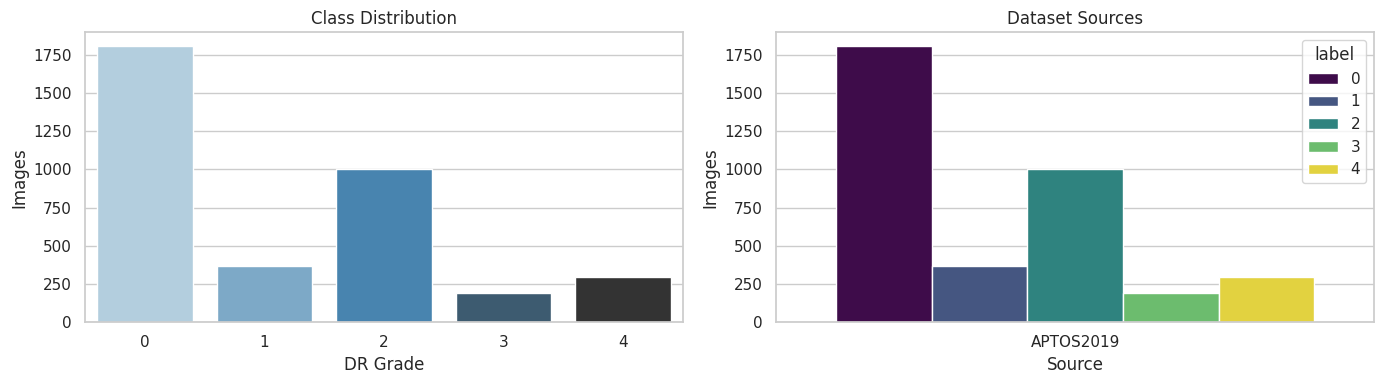

[PosixPath('/kaggle/working/dr_hybrid_project/notebook_artifacts/tables/dataset_source_class_counts.csv'),
 PosixPath('/kaggle/working/dr_hybrid_project/notebook_artifacts/tables/dataset_source_class_counts.tex')]

In [8]:
train_frame = build_training_frame(CFG)
aptos_test_frame = build_aptos_test_frame(CFG)

print("Training samples:", len(train_frame))
print("APTOS test samples:", len(aptos_test_frame))
dataset_source_distribution = train_frame.groupby(["source", "label"]).size().unstack(fill_value=0)
dataset_source_distribution = dataset_source_distribution.rename(
    columns={class_idx: CLASS_NAMES[class_idx] for class_idx in range(CFG.num_classes)}
)
dataset_overall_class_counts = (
    train_frame["label"]
    .value_counts()
    .sort_index()
    .rename("count")
    .rename_axis("label")
    .reset_index()
)
dataset_overall_class_counts["class_name"] = dataset_overall_class_counts["label"].map(
    lambda class_idx: CLASS_NAMES[int(class_idx)]
)
dataset_overall_class_counts = dataset_overall_class_counts[["label", "class_name", "count"]]
dataset_source_class_counts = dataset_source_distribution.reset_index()

display(train_frame.head())
display(dataset_source_distribution)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(
    data=train_frame,
    x="label",
    hue="label",
    order=range(CFG.num_classes),
    hue_order=range(CFG.num_classes),
    ax=axes[0],
    palette="Blues_d",
    legend=False,
)
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("DR Grade")
axes[0].set_ylabel("Images")

sns.countplot(data=train_frame, x="source", hue="label", ax=axes[1], palette="viridis")
axes[1].set_title("Dataset Sources")
axes[1].set_xlabel("Source")
axes[1].set_ylabel("Images")
plt.tight_layout()
save_figure(fig, "dataset_distribution.png")
plt.show()

export_table_bundle(dataset_overall_class_counts, "dataset_overall_class_counts", include_index=False)
export_table_bundle(dataset_source_class_counts, "dataset_source_class_counts", include_index=False)

In [9]:
def choose_stratify_targets(frame: pd.DataFrame) -> pd.Series:
    if "source" in frame.columns and frame["source"].nunique() > 1:
        joint_targets = frame["source"].astype(str) + "__" + frame["label"].astype(str)
        if joint_targets.value_counts().min() >= 2:
            return joint_targets
    return frame["label"].astype(str)


def stratified_split_frame(frame: pd.DataFrame, test_size: float, seed: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    splitter = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=seed,
    )
    stratify_targets = choose_stratify_targets(frame)
    train_idx, test_idx = next(splitter.split(frame, stratify_targets))
    train_df = frame.iloc[train_idx].reset_index(drop=True)
    test_df = frame.iloc[test_idx].reset_index(drop=True)
    return train_df, test_df


def make_research_splits(
    frame: pd.DataFrame,
    val_size: float,
    calibration_size: float,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if val_size <= 0 or calibration_size < 0 or (val_size + calibration_size) >= 1:
        raise ValueError("Expected val_size > 0, calibration_size >= 0, and val_size + calibration_size < 1.")

    train_calibration_df, val_df = stratified_split_frame(frame, test_size=val_size, seed=seed)

    if calibration_size == 0:
        calibration_df = pd.DataFrame(columns=frame.columns)
        train_df = train_calibration_df.reset_index(drop=True)
    else:
        calibration_fraction = calibration_size / (1.0 - val_size)
        train_df, calibration_df = stratified_split_frame(
            train_calibration_df,
            test_size=calibration_fraction,
            seed=seed + 1,
        )

    return train_df, calibration_df.reset_index(drop=True), val_df.reset_index(drop=True)


train_df, calibration_df, val_df = make_research_splits(
    train_frame,
    val_size=CFG.val_size,
    calibration_size=CFG.calibration_size,
    seed=CFG.seed,
)

print("Train split:", train_df.shape)
print("Calibration split:", calibration_df.shape)
print("Validation split:", val_df.shape)
split_class_distribution = pd.concat(
    [
        train_df["label"].value_counts().sort_index().rename("train"),
        calibration_df["label"].value_counts().sort_index().rename("calibration"),
        val_df["label"].value_counts().sort_index().rename("validation"),
    ],
    axis=1,
).fillna(0).astype(int)
split_class_distribution.index = [CLASS_NAMES[int(class_idx)] for class_idx in split_class_distribution.index]
split_class_distribution.index.name = "class_name"

split_source_label_distribution = pd.concat(
    [
        train_df.groupby(["source", "label"]).size().rename("train"),
        calibration_df.groupby(["source", "label"]).size().rename("calibration"),
        val_df.groupby(["source", "label"]).size().rename("validation"),
    ],
    axis=1,
).fillna(0).astype(int).reset_index()
split_source_label_distribution["class_name"] = split_source_label_distribution["label"].map(
    lambda class_idx: CLASS_NAMES[int(class_idx)]
)
split_source_label_distribution = split_source_label_distribution[
    ["source", "label", "class_name", "train", "calibration", "validation"]
]

display(split_class_distribution)
display(split_source_label_distribution)
export_table_bundle(split_class_distribution, "split_class_distribution", include_index=True)
export_table_bundle(split_source_label_distribution, "split_source_label_distribution", include_index=False)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        (CFG.image_size, CFG.image_size),
        scale=(0.92, 1.0),
        ratio=(0.96, 1.04),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply(
        [
            transforms.RandomAffine(
                degrees=10,
                translate=(0.04, 0.04),
                scale=(0.95, 1.05),
            )
        ],
        p=0.35,
    ),
    transforms.ColorJitter(brightness=0.16, contrast=0.16, saturation=0.12, hue=0.015),
    transforms.RandomAutocontrast(p=0.08),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.6))], p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.08, scale=(0.02, 0.04), ratio=(0.5, 2.0), value="random"),
])

eval_transform = transforms.Compose([
    transforms.Resize((CFG.image_size, CFG.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

Train split: (2562, 4)
Calibration split: (367, 4)
Validation split: (733, 4)


,train,calibration,validation
class_name,,,
No_DR,1263,181,361
Mild,259,37,74
Moderate,699,100,200
Severe,135,19,39
Proliferative_DR,206,30,59


,source,label,class_name,train,calibration,validation
0,APTOS2019,0,No_DR,1263,181,361
1,APTOS2019,1,Mild,259,37,74
2,APTOS2019,2,Moderate,699,100,200
3,APTOS2019,3,Severe,135,19,39
4,APTOS2019,4,Proliferative_DR,206,30,59


In [10]:
class RetinopathyDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform, cfg: Config, cache_dir: Path | None = None):
        self.frame = frame.reset_index(drop=True).copy()
        self.transform = transform
        self.cfg = cfg
        self.cache_dir = Path(cache_dir) if cache_dir is not None else None
        if self.cache_dir is not None:
            self.cache_dir.mkdir(parents=True, exist_ok=True)

    def __len__(self) -> int:
        return len(self.frame)

    def _cache_path(self, row: pd.Series) -> Path | None:
        if self.cache_dir is None:
            return None
        image_stem = Path(str(row["image_path"])).stem
        cache_name = f"{image_stem}_{self.cfg.image_size}_clahe{int(self.cfg.apply_clahe)}.npy"
        return self.cache_dir / cache_name

    def _load_image(self, row: pd.Series) -> Image.Image:
        cache_path = self._cache_path(row)
        if cache_path is not None and cache_path.exists():
            with cache_path.open("rb") as handle:
                cached_image = np.load(handle, allow_pickle=False)
            return Image.fromarray(cached_image)

        image = load_retina_image(row["image_path"], self.cfg.image_size, apply_clahe=self.cfg.apply_clahe)
        if cache_path is not None:
            image_array = np.asarray(image, dtype=np.uint8)
            tmp_path = cache_path.with_suffix(f"{cache_path.suffix}.{os.getpid()}.tmp")
            try:
                with tmp_path.open("wb") as handle:
                    np.save(handle, image_array, allow_pickle=False)
                os.replace(tmp_path, cache_path)
            except OSError:
                if tmp_path.exists():
                    tmp_path.unlink(missing_ok=True)
            return Image.fromarray(image_array)
        return image

    def __getitem__(self, index: int) -> dict:
        row = self.frame.iloc[index]
        image = self._load_image(row)
        image_tensor = self.transform(image)

        batch = {
            "image": image_tensor,
            "image_id": row["image_id"],
            "image_path": row["image_path"],
        }
        if "label" in row.index:
            batch["label"] = torch.tensor(int(row["label"]), dtype=torch.long)
        return batch


def build_sampling_tools(
    labels: pd.Series,
    num_classes: int,
    balance_power: float = 1.0,
    max_weight: float | None = None,
) -> tuple[WeightedRandomSampler, torch.Tensor]:
    counts = labels.value_counts().reindex(range(num_classes), fill_value=0)
    adjusted_counts = counts.replace(0, 1)
    inverse_frequency = len(labels) / (num_classes * adjusted_counts)
    class_weights = inverse_frequency.pow(balance_power)
    class_weights = class_weights / class_weights.mean()
    if max_weight is not None:
        class_weights = class_weights.clip(lower=0.75, upper=float(max_weight))
        class_weights = class_weights / class_weights.mean()
    sample_weights = labels.map(class_weights).to_numpy()
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )
    return sampler, torch.as_tensor(class_weights.to_numpy(), dtype=torch.float32)


def build_loss_class_weights(
    labels: pd.Series,
    num_classes: int,
    balance_power: float = 0.35,
    min_weight: float = 0.85,
    max_weight: float = 1.75,
    advanced_class_start: int = 3,
    advanced_boost: float = 0.0,
) -> torch.Tensor:
    counts = labels.value_counts().reindex(range(num_classes), fill_value=0)
    adjusted_counts = counts.replace(0, 1)
    inverse_frequency = len(labels) / (num_classes * adjusted_counts)
    class_weights = inverse_frequency.pow(balance_power)
    class_weights = class_weights / class_weights.mean()
    if advanced_boost > 0:
        advanced_mask = class_weights.index.to_series().ge(int(advanced_class_start))
        class_weights.loc[advanced_mask] = class_weights.loc[advanced_mask] * (1.0 + float(advanced_boost))
    class_weights = class_weights.clip(lower=float(min_weight), upper=float(max_weight))
    class_weights = class_weights / class_weights.mean()
    return torch.as_tensor(class_weights.to_numpy(), dtype=torch.float32)


preprocessed_cache_root = WORKDIR / "preprocessed_cache" if CFG.cache_preprocessed_images else None
train_dataset = RetinopathyDataset(
    train_df,
    train_transform,
    CFG,
    cache_dir=preprocessed_cache_root / "train" if preprocessed_cache_root is not None else None,
)
calibration_dataset = RetinopathyDataset(
    calibration_df,
    eval_transform,
    CFG,
    cache_dir=preprocessed_cache_root / "calibration" if preprocessed_cache_root is not None else None,
)
val_dataset = RetinopathyDataset(
    val_df,
    eval_transform,
    CFG,
    cache_dir=preprocessed_cache_root / "validation" if preprocessed_cache_root is not None else None,
)
train_sampler, class_weights = build_sampling_tools(
    train_df["label"],
    CFG.num_classes,
    balance_power=CFG.class_balance_power,
    max_weight=CFG.sampler_weight_cap,
)
loss_class_weights = build_loss_class_weights(
    train_df["label"],
    CFG.num_classes,
    balance_power=CFG.loss_class_balance_power,
    min_weight=CFG.loss_weight_floor,
    max_weight=CFG.loss_weight_cap,
    advanced_class_start=CFG.advanced_class_start,
    advanced_boost=CFG.advanced_class_boost,
)
loader_kwargs = {
    "num_workers": CFG.num_workers,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": CFG.num_workers > 0,
}
if CFG.num_workers > 0:
    loader_kwargs["prefetch_factor"] = max(2, int(CFG.prefetch_factor))

train_sampler = train_sampler if CFG.use_weighted_sampler else None
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    sampler=train_sampler,
    shuffle=train_sampler is None,
    drop_last=True,
    **loader_kwargs,
)

calibration_loader = DataLoader(
    calibration_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    **loader_kwargs,
)

print("Sampler class weights:", class_weights.tolist())
print("Loss class weights:", loss_class_weights.tolist())
print("Weighted sampler enabled:", CFG.use_weighted_sampler)
print("DataLoader workers per loader:", loader_kwargs["num_workers"])
print("Persistent workers enabled:", loader_kwargs["persistent_workers"])
print("Prefetch factor:", loader_kwargs.get("prefetch_factor", "n/a"))
print("Preprocessed image cache enabled:", CFG.cache_preprocessed_images)
print("Train batches:", len(train_loader))
print("Calibration batches:", len(calibration_loader))
print("Validation batches:", len(val_loader))

Sampler class weights: [0.6702211499214172, 0.9754368662834167, 0.6702211499214172, 1.5391302108764648, 1.1449906826019287]
Loss class weights: [0.6884153485298157, 0.8764463663101196, 0.6884153485298157, 1.417325735092163, 1.329397201538086]
Weighted sampler enabled: True
DataLoader workers per loader: 4
Persistent workers enabled: True
Prefetch factor: 4
Preprocessed image cache enabled: True
Train batches: 80
Calibration batches: 12
Validation batches: 23


## Hybrid Model

The architecture uses:

- **EfficientNet-B3** by default to capture stronger local lesion-level texture and vascular cues
- **DeiT-Tiny** to capture wider retinal context
- a learned fusion block that mixes local, global, interaction, and disagreement signals
- a standard **5-class classifier head**
- a parallel **ordinal head** that regularizes the training process for ordered DR grades

Recommended backbone choices for a free Kaggle GPU:

- `efficientnet_b3`: best balance of accuracy and runtime for this notebook
- `tf_efficientnetv2_s`: stronger but slower, better if you stay on APTOS only
- `mobilevitv2_150`: lighter fallback if memory or time gets tight

In [11]:
def create_timm_backbone(model_name: str, pretrained: bool = True):
    try:
        return timm.create_model(model_name, pretrained=pretrained)
    except Exception as error:
        print(f"Falling back to pretrained=False for {model_name}: {error}")
        return timm.create_model(model_name, pretrained=False)


class HybridDRClassifier(nn.Module):
    def __init__(
        self,
        num_classes: int = 5,
        pretrained: bool = True,
        fusion_dim: int = 384,
        cnn_backbone: str = "efficientnet_b3",
        vit_backbone: str = "deit_tiny_patch16_224",
    ):
        super().__init__()
        self.cnn_name = cnn_backbone
        self.vit_name = vit_backbone
        self.cnn = create_timm_backbone(cnn_backbone, pretrained=pretrained)
        self.vit = create_timm_backbone(vit_backbone, pretrained=pretrained)

        cnn_dim = self.cnn.num_features
        vit_dim = self.vit.num_features

        self.cnn_projection = nn.Sequential(
            nn.Linear(cnn_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(0.20),
        )

        self.vit_projection = nn.Sequential(
            nn.Linear(vit_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(0.20),
        )

        fusion_input_dim = fusion_dim * 4
        self.fusion_block = nn.Sequential(
            nn.Linear(fusion_input_dim, fusion_dim * 2),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.GELU(),
            nn.Dropout(0.20),
        )

        self.classifier = nn.Linear(fusion_dim, num_classes)
        self.ordinal_head = nn.Linear(fusion_dim, num_classes - 1)

    def forward(self, images: torch.Tensor) -> dict[str, torch.Tensor]:
        cnn_maps = self.cnn.forward_features(images)
        cnn_vector = self.cnn.forward_head(cnn_maps, pre_logits=True)
        if cnn_vector.ndim > 2:
            cnn_vector = torch.flatten(cnn_vector, 1)

        vit_tokens = self.vit.forward_features(images)
        vit_cls = vit_tokens[:, 0]

        cnn_repr = self.cnn_projection(cnn_vector)
        vit_repr = self.vit_projection(vit_cls)

        interaction = cnn_repr * vit_repr
        disagreement = torch.abs(cnn_repr - vit_repr)
        fused_features = self.fusion_block(torch.cat([cnn_repr, vit_repr, interaction, disagreement], dim=1))

        logits = self.classifier(fused_features)
        ordinal_logits = self.ordinal_head(fused_features)

        return {
            "logits": logits,
            "ordinal_logits": ordinal_logits,
            "cnn_maps": cnn_maps,
            "vit_tokens": vit_tokens,
            "fused_features": fused_features,
        }


model = HybridDRClassifier(
    num_classes=CFG.num_classes,
    pretrained=CFG.pretrained_backbones,
    cnn_backbone=CFG.cnn_backbone,
    vit_backbone=CFG.vit_backbone,
).to(DEVICE)
if USE_CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)
total_params = sum(parameter.numel() for parameter in model.parameters()) / 1_000_000
print(f"Trainable parameters: {total_params:.2f}M")
print("CNN backbone:", CFG.cnn_backbone)
print("Transformer backbone:", CFG.vit_backbone)

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Trainable parameters: 20.10M
CNN backbone: efficientnet_b3
Transformer backbone: deit_tiny_patch16_224


In [12]:
def make_ordinal_targets(labels: torch.Tensor, num_classes: int) -> torch.Tensor:
    thresholds = torch.arange(num_classes - 1, device=labels.device).unsqueeze(0)
    return (labels.unsqueeze(1) > thresholds).float()


class HybridOrdinalLoss(nn.Module):
    def __init__(
        self,
        num_classes: int,
        class_weights: torch.Tensor | None = None,
        ordinal_weight: float = 0.40,
        distance_weight: float = 0.15,
        hard_example_gamma: float = 1.25,
        label_smoothing: float = 0.0,
        advanced_class_start: int = 3,
        advanced_class_boost: float = 0.0,
        undergrading_penalty_weight: float = 0.0,
        undergrading_margin_power: float = 1.5,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.ordinal_weight = ordinal_weight
        self.distance_weight = distance_weight
        self.hard_example_gamma = hard_example_gamma
        self.label_smoothing = label_smoothing
        self.advanced_class_start = int(advanced_class_start)
        self.advanced_class_boost = float(advanced_class_boost)
        self.undergrading_penalty_weight = float(undergrading_penalty_weight)
        self.undergrading_margin_power = float(undergrading_margin_power)
        self.register_buffer("grade_values", torch.arange(num_classes, dtype=torch.float32))

        if class_weights is None:
            self.class_weights = None
        else:
            self.register_buffer("class_weights", class_weights.float())

    def forward(self, outputs: dict[str, torch.Tensor], labels: torch.Tensor) -> torch.Tensor:
        logits = outputs["logits"]
        ordinal_logits = outputs["ordinal_logits"]

        ce_loss = F.cross_entropy(
            logits,
            labels,
            reduction="none",
            weight=self.class_weights,
            label_smoothing=self.label_smoothing,
        )
        ordinal_targets = make_ordinal_targets(labels, self.num_classes)
        ordinal_loss = F.binary_cross_entropy_with_logits(ordinal_logits, ordinal_targets, reduction="none").mean(dim=1)

        probabilities = logits.softmax(dim=1)
        true_class_prob = probabilities.gather(1, labels.unsqueeze(1)).squeeze(1)
        grade_values = self.grade_values.to(device=probabilities.device, dtype=probabilities.dtype)
        expected_grade = (probabilities * grade_values).sum(dim=1)
        distance_penalty = (expected_grade - labels.float()).pow(2)
        undergrading_margin = F.relu(labels.float() - expected_grade)

        adjacent_mass = torch.zeros_like(true_class_prob)
        for shift in (-1, 1):
            neighbor = labels + shift
            valid = (neighbor >= 0) & (neighbor < self.num_classes)
            adjacent_mass[valid] += probabilities[valid, neighbor[valid]]

        advanced_mask = (labels >= self.advanced_class_start).float()
        advanced_focus = 1.0 + advanced_mask * self.advanced_class_boost
        hard_weight = (
            1.0
            + self.hard_example_gamma * (1.0 - true_class_prob).pow(2)
            + 0.30 * adjacent_mass
            + 0.20 * distance_penalty.sqrt()
        )
        main_loss = ce_loss + self.ordinal_weight * ordinal_loss + self.distance_weight * distance_penalty
        undergrading_penalty = advanced_mask * undergrading_margin.pow(self.undergrading_margin_power)
        total_loss = advanced_focus * hard_weight * main_loss + self.undergrading_penalty_weight * undergrading_penalty
        return total_loss.mean()


def safe_multiclass_auc(y_true: np.ndarray, y_prob: np.ndarray, num_classes: int) -> float:
    try:
        y_true_binary = label_binarize(y_true, classes=list(range(num_classes)))
        return float(roc_auc_score(y_true_binary, y_prob, average="macro", multi_class="ovr"))
    except ValueError:
        return float("nan")


def negative_log_likelihood(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    if len(y_true) == 0:
        return float("nan")
    clipped = np.clip(y_prob, 1e-7, 1.0)
    return float(-np.log(clipped[np.arange(len(y_true)), y_true]).mean())


def expected_calibration_error(y_true: np.ndarray, y_pred: np.ndarray, confidences: np.ndarray, num_bins: int = 10) -> float:
    if len(y_true) == 0:
        return float("nan")

    confidences = np.asarray(confidences, dtype=np.float32)
    correctness = (y_pred == y_true).astype(np.float32)
    bin_edges = np.linspace(0.0, 1.0, num_bins + 1)
    ece = 0.0

    for start, end in zip(bin_edges[:-1], bin_edges[1:]):
        if end == 1.0:
            in_bin = (confidences >= start) & (confidences <= end)
        else:
            in_bin = (confidences >= start) & (confidences < end)
        if not np.any(in_bin):
            continue
        bin_accuracy = correctness[in_bin].mean()
        bin_confidence = confidences[in_bin].mean()
        ece += np.abs(bin_accuracy - bin_confidence) * in_bin.mean()

    return float(ece)


def logits_to_probabilities(logits: np.ndarray, temperature: float = 1.0) -> np.ndarray:
    temperature = max(float(temperature), 1e-3)
    logits_tensor = torch.as_tensor(logits, dtype=torch.float32)
    return torch.softmax(logits_tensor / temperature, dim=1).cpu().numpy()


def compute_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_prob: np.ndarray,
    num_classes: int,
    predicted_confidences: np.ndarray | None = None,
) -> dict[str, float]:
    if len(y_true) == 0:
        return {
            "accuracy": float("nan"),
            "balanced_accuracy": float("nan"),
            "macro_f1": float("nan"),
            "weighted_f1": float("nan"),
            "qwk": float("nan"),
            "macro_auc_ovr": float("nan"),
            "adjacent_error_rate": float("nan"),
            "minority_recall": float("nan"),
            "min_class_recall": float("nan"),
            "nll": float("nan"),
            "ece": float("nan"),
        }

    if predicted_confidences is None:
        predicted_confidences = y_prob.max(axis=1)
    else:
        predicted_confidences = np.asarray(predicted_confidences, dtype=np.float32)

    _, recalls, _, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        zero_division=0,
    )
    recalls = np.asarray(recalls, dtype=np.float32)
    if len(recalls) >= 2:
        minority_recall = float(recalls[-2:].mean())
    else:
        minority_recall = float(recalls.mean())

    adjacent_errors = ((np.abs(y_true - y_pred) == 1) & (y_true != y_pred)).mean()
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "qwk": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
        "macro_auc_ovr": safe_multiclass_auc(y_true, y_prob, num_classes),
        "adjacent_error_rate": float(adjacent_errors),
        "minority_recall": minority_recall,
        "min_class_recall": float(recalls.min()),
        "nll": negative_log_likelihood(y_true, y_prob),
        "ece": expected_calibration_error(y_true, y_pred, predicted_confidences),
    }


In [13]:
class TrainingProgressWidget:
    def __init__(self, total_epochs: int, enabled: bool = True):
        self.enabled = bool(enabled)
        self.total_epochs = max(int(total_epochs), 1)
        self.current_epoch = 0
        self.total_steps = 1
        self.phase_name = "Idle"
        self.update_interval = 1

        if not self.enabled:
            return

        try:
            self.header = widgets.HTML("<b>Hybrid DR training dashboard</b>")
            self.status = widgets.HTML("Waiting to start")
            self.epoch_bar = widgets.IntProgress(
                value=0,
                min=0,
                max=self.total_epochs,
                description="Epoch",
                bar_style="info",
            )
            self.step_bar = widgets.IntProgress(
                value=0,
                min=0,
                max=1,
                description="Batches",
                bar_style="",
            )
            self.metrics = widgets.HTML("No metrics yet")
            display(widgets.VBox([self.header, self.status, self.epoch_bar, self.step_bar, self.metrics]))
        except Exception as error:
            self.enabled = False
            print(f"Falling back to text logs because the notebook widget could not initialize: {error}")

    def start_epoch(self, epoch: int) -> None:
        self.current_epoch = int(epoch)
        if not self.enabled:
            return
        self.epoch_bar.value = max(0, epoch - 1)
        self.status.value = f"<b>Epoch {epoch}/{self.total_epochs}</b> | preparing..."

    def start_phase(self, phase_name: str, total_steps: int) -> None:
        self.phase_name = phase_name
        self.total_steps = max(int(total_steps), 1)
        self.update_interval = 1 if self.total_steps <= 20 else max(1, self.total_steps // 20)
        if not self.enabled:
            return
        self.step_bar.max = self.total_steps
        self.step_bar.value = 0
        self.step_bar.description = phase_name
        self.step_bar.bar_style = "info" if phase_name.lower().startswith("train") else "warning"
        self.status.value = f"<b>Epoch {self.current_epoch}/{self.total_epochs}</b> | {phase_name} started"

    def update_batch(self, step: int, loss: float, lr: float | None = None) -> None:
        if not self.enabled:
            return
        if step % self.update_interval != 0 and step != self.total_steps:
            return
        self.step_bar.value = min(step, self.total_steps)
        lr_text = f" | lr={lr:.6f}" if lr is not None else ""
        self.status.value = (
            f"<b>Epoch {self.current_epoch}/{self.total_epochs}</b> | "
            f"{self.phase_name} {step}/{self.total_steps} | loss={loss:.4f}{lr_text}"
        )

    def update_epoch_summary(self, row: dict[str, float], best_score: float, best_accuracy: float) -> None:
        if not self.enabled:
            return
        self.epoch_bar.value = min(int(row["epoch"]), self.total_epochs)
        self.step_bar.value = self.step_bar.max
        self.step_bar.bar_style = "success"
        self.metrics.value = (
            "<table>"
            f"<tr><td><b>Stage</b></td><td>{row['stage']}</td></tr>"
            f"<tr><td><b>Train loss</b></td><td>{row['train_loss']:.4f}</td></tr>"
            f"<tr><td><b>Val loss</b></td><td>{row['val_loss']:.4f}</td></tr>"
            f"<tr><td><b>Train acc</b></td><td>{row['train_accuracy']:.4f}</td></tr>"
            f"<tr><td><b>Val acc</b></td><td>{row['val_accuracy']:.4f}</td></tr>"
            f"<tr><td><b>Val bal acc</b></td><td>{row['val_balanced_accuracy']:.4f}</td></tr>"
            f"<tr><td><b>Val QWK</b></td><td>{row['val_qwk']:.4f}</td></tr>"
            f"<tr><td><b>Val macro F1</b></td><td>{row['val_macro_f1']:.4f}</td></tr>"
            f"<tr><td><b>Val weighted F1</b></td><td>{row['val_weighted_f1']:.4f}</td></tr>"
            f"<tr><td><b>Val minority recall</b></td><td>{row['val_minority_recall']:.4f}</td></tr>"
            f"<tr><td><b>Val min recall</b></td><td>{row['val_min_class_recall']:.4f}</td></tr>"
            f"<tr><td><b>Acc gap</b></td><td>{row['accuracy_gap']:.4f}</td></tr>"
            f"<tr><td><b>Val ECE</b></td><td>{row['val_ece']:.4f}</td></tr>"
            f"<tr><td><b>Selection score</b></td><td>{row['selection_score']:.4f}</td></tr>"
            f"<tr><td><b>Head lr</b></td><td>{row['head_lr']:.6f}</td></tr>"
            f"<tr><td><b>Backbone lr</b></td><td>{row['backbone_lr']:.6f}</td></tr>"
            f"<tr><td><b>Best score</b></td><td>{best_score:.4f}</td></tr>"
            f"<tr><td><b>Best val acc</b></td><td>{best_accuracy:.4f}</td></tr>"
            "</table>"
        )
        self.status.value = f"<b>Epoch {self.current_epoch}/{self.total_epochs}</b> | finished"

    def finish(self) -> None:
        if not self.enabled:
            return
        self.step_bar.bar_style = "success"
        self.status.value = self.status.value + " | training complete"


def compute_selection_score(row: dict[str, float]) -> float:
    generalization_penalty = (
        0.22 * max(row["train_accuracy"] - row["val_accuracy"], 0.0)
        + 0.10 * max(row["train_balanced_accuracy"] - row["val_balanced_accuracy"], 0.0)
        + 0.18 * max(row["train_qwk"] - row["val_qwk"], 0.0)
        + 0.12 * max(row["train_macro_f1"] - row["val_macro_f1"], 0.0)
        + 0.22 * max(row["train_minority_recall"] - row["val_minority_recall"], 0.0)
        + 0.16 * max(row["train_min_class_recall"] - row["val_min_class_recall"], 0.0)
    )
    calibration_penalty = max(row["val_ece"] - 0.08, 0.0)
    stage_penalty = 0.04 if row.get("stage") == "head_warmup" else 0.0
    return float(
        0.28 * row["val_qwk"]
        + 0.16 * row["val_accuracy"]
        + 0.12 * row["val_macro_f1"]
        + 0.12 * row["val_balanced_accuracy"]
        + 0.22 * row["val_minority_recall"]
        + 0.10 * row["val_min_class_recall"]
        - 0.14 * generalization_penalty
        - 0.03 * calibration_penalty
        - stage_penalty
    )


def split_optimizer_groups(model: nn.Module) -> tuple[list[nn.Parameter], list[nn.Parameter]]:
    head_prefixes = (
        "cnn_projection",
        "vit_projection",
        "fusion_block",
        "classifier",
        "ordinal_head",
    )
    backbone_params, head_params = [], []
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        if any(name.startswith(prefix) for prefix in head_prefixes):
            head_params.append(parameter)
        else:
            backbone_params.append(parameter)
    return backbone_params, head_params


def set_backbone_trainable(model: nn.Module, enabled: bool) -> None:
    for parameter in model.cnn.parameters():
        parameter.requires_grad = enabled
    for parameter in model.vit.parameters():
        parameter.requires_grad = enabled

    for block in [model.cnn_projection, model.vit_projection, model.fusion_block, model.classifier, model.ordinal_head]:
        for parameter in block.parameters():
            parameter.requires_grad = True


def get_current_lrs(optimizer: torch.optim.Optimizer) -> tuple[float, float]:
    if not optimizer.param_groups:
        return float("nan"), float("nan")
    backbone_lr = float(optimizer.param_groups[0]["lr"])
    head_lr = float(optimizer.param_groups[-1]["lr"])
    return backbone_lr, head_lr


class ExponentialMovingAverage:
    def __init__(self, model: nn.Module, decay: float):
        self.decay = float(decay)
        self.module = copy.deepcopy(model).eval()
        for parameter in self.module.parameters():
            parameter.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        model_state = model.state_dict()
        for name, ema_value in self.module.state_dict().items():
            model_value = model_state[name].detach()
            if ema_value.dtype.is_floating_point:
                ema_value.mul_(self.decay).add_(model_value, alpha=1.0 - self.decay)
            else:
                ema_value.copy_(model_value)


def build_epoch_scheduler(optimizer: torch.optim.Optimizer, cfg: Config):
    if cfg.epochs <= 1:
        return None

    warmup_epochs = min(cfg.warmup_epochs, max(cfg.epochs - 1, 0))
    if warmup_epochs > 0:
        warmup = torch.optim.lr_scheduler.LinearLR(
            optimizer,
            start_factor=0.35,
            end_factor=1.0,
            total_iters=warmup_epochs,
        )
        cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(cfg.epochs - warmup_epochs, 1),
            eta_min=cfg.min_lr,
        )
        return torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[warmup, cosine],
            milestones=[warmup_epochs],
        )

    return torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(cfg.epochs, 1),
        eta_min=cfg.min_lr,
    )


def prepare_batch_images(images: torch.Tensor) -> torch.Tensor:
    images = images.to(DEVICE, non_blocking=torch.cuda.is_available())
    if USE_CHANNELS_LAST:
        images = images.contiguous(memory_format=torch.channels_last)
    return images


def get_autocast_context():
    return torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP) if USE_AMP else nullcontext()


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None = None,
    scaler: torch.amp.GradScaler | None = None,
    max_grad_norm: float | None = None,
    progress_widget: TrainingProgressWidget | None = None,
    phase_name: str = "Train",
    ema_model: ExponentialMovingAverage | None = None,
) -> dict:
    training = optimizer is not None
    model.train(training)
    if training and hasattr(model, "cnn") and not any(parameter.requires_grad for parameter in model.cnn.parameters()):
        model.cnn.eval()
    if training and hasattr(model, "vit") and not any(parameter.requires_grad for parameter in model.vit.parameters()):
        model.vit.eval()

    all_targets = []
    all_predictions = []
    all_probabilities = []
    running_loss = []

    if progress_widget is not None:
        progress_widget.start_phase(phase_name, len(loader))

    for step, batch in enumerate(loader, start=1):
        images = prepare_batch_images(batch["image"])
        labels = batch["label"].to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        grad_context = nullcontext() if training else torch.no_grad()
        autocast_context = get_autocast_context()

        with grad_context:
            with autocast_context:
                outputs = model(images)
                loss = criterion(outputs, labels)

            if training:
                scaler.scale(loss).backward()
                if max_grad_norm is not None and max_grad_norm > 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
                if ema_model is not None:
                    ema_model.update(model)

        probabilities = outputs["logits"].float().softmax(dim=1).detach().cpu().numpy()
        predictions = probabilities.argmax(axis=1)

        all_targets.append(labels.detach().cpu().numpy())
        all_predictions.append(predictions)
        all_probabilities.append(probabilities)
        running_loss.append(float(loss.item()))

        if progress_widget is not None:
            current_lr = float(optimizer.param_groups[0]["lr"]) if training else None
            progress_widget.update_batch(step, float(np.mean(running_loss)), current_lr)

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_predictions)
    y_prob = np.concatenate(all_probabilities)
    metrics = compute_metrics(y_true, y_pred, y_prob, CFG.num_classes)

    return {
        "loss": float(np.mean(running_loss)),
        "metrics": metrics,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }


def fit_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    cfg: Config,
) -> tuple[pd.DataFrame, Path]:
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)
    best_qwk = -float("inf")
    best_accuracy = -float("inf")
    best_score = -float("inf")
    history = []
    checkpoint_path = WORKDIR / "best_hybrid_dr_classifier.pt"
    epochs_without_improvement = 0
    progress_widget = TrainingProgressWidget(cfg.epochs, enabled=cfg.use_training_widgets)
    ema_model = ExponentialMovingAverage(model, cfg.ema_decay) if cfg.use_ema else None
    current_stage = None

    for epoch in range(1, cfg.epochs + 1):
        progress_widget.start_epoch(epoch)
        backbone_trainable = epoch > cfg.freeze_backbone_epochs
        stage_name = "full_finetune" if backbone_trainable else "head_warmup"
        if stage_name != current_stage:
            set_backbone_trainable(model, enabled=backbone_trainable)
            current_stage = stage_name
            print(f"Training stage: {stage_name} (epoch {epoch})")

        train_result = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            scaler=scaler,
            max_grad_norm=cfg.max_grad_norm,
            progress_widget=progress_widget,
            phase_name="Train",
            ema_model=ema_model,
        )
        eval_model = ema_model.module if ema_model is not None else model
        val_result = run_epoch(
            eval_model,
            val_loader,
            criterion,
            optimizer=None,
            scaler=scaler,
            progress_widget=progress_widget,
            phase_name="Validation",
        )
        backbone_lr, head_lr = get_current_lrs(optimizer)

        row = {
            "epoch": epoch,
            "stage": stage_name,
            "train_loss": train_result["loss"],
            "val_loss": val_result["loss"],
            "train_accuracy": train_result["metrics"]["accuracy"],
            "train_balanced_accuracy": train_result["metrics"]["balanced_accuracy"],
            "train_qwk": train_result["metrics"]["qwk"],
            "val_qwk": val_result["metrics"]["qwk"],
            "train_macro_f1": train_result["metrics"]["macro_f1"],
            "train_weighted_f1": train_result["metrics"]["weighted_f1"],
            "train_minority_recall": train_result["metrics"]["minority_recall"],
            "train_min_class_recall": train_result["metrics"]["min_class_recall"],
            "val_macro_f1": val_result["metrics"]["macro_f1"],
            "val_weighted_f1": val_result["metrics"]["weighted_f1"],
            "val_minority_recall": val_result["metrics"]["minority_recall"],
            "val_min_class_recall": val_result["metrics"]["min_class_recall"],
            "val_accuracy": val_result["metrics"]["accuracy"],
            "val_balanced_accuracy": val_result["metrics"]["balanced_accuracy"],
            "val_auc": val_result["metrics"]["macro_auc_ovr"],
            "train_ece": train_result["metrics"]["ece"],
            "val_ece": val_result["metrics"]["ece"],
            "train_nll": train_result["metrics"]["nll"],
            "val_nll": val_result["metrics"]["nll"],
            "accuracy_gap": train_result["metrics"]["accuracy"] - val_result["metrics"]["accuracy"],
            "qwk_gap": train_result["metrics"]["qwk"] - val_result["metrics"]["qwk"],
            "macro_f1_gap": train_result["metrics"]["macro_f1"] - val_result["metrics"]["macro_f1"],
            "backbone_lr": backbone_lr,
            "head_lr": head_lr,
            "monitor_model": "ema" if ema_model is not None else "base",
        }
        row["selection_score"] = compute_selection_score(row)
        history.append(row)

        print(
            f"Epoch {epoch:02d} | "
            f"stage={row['stage']} | "
            f"train_acc={row['train_accuracy']:.4f} | val_acc={row['val_accuracy']:.4f} | "
            f"val_bal_acc={row['val_balanced_accuracy']:.4f} | val_qwk={row['val_qwk']:.4f} | "
            f"val_macro_f1={row['val_macro_f1']:.4f} | val_minority_recall={row['val_minority_recall']:.4f} | "
            f"gap={row['accuracy_gap']:.4f} | score={row['selection_score']:.4f} | head_lr={row['head_lr']:.6f} | "
            f"backbone_lr={row['backbone_lr']:.6f}"
        )

        best_qwk = max(best_qwk, row["val_qwk"])
        best_accuracy = max(best_accuracy, row["val_accuracy"])

        if row["selection_score"] > best_score:
            best_score = row["selection_score"]
            epochs_without_improvement = 0
            torch.save(
                {
                    "model_state": eval_model.state_dict(),
                    "config": asdict(cfg),
                    "history_row": row,
                    "best_score": best_score,
                    "best_qwk": best_qwk,
                    "best_val_accuracy": best_accuracy,
                },
                checkpoint_path,
            )
        else:
            epochs_without_improvement += 1

        progress_widget.update_epoch_summary(row, best_score, best_accuracy)

        if scheduler is not None:
            scheduler.step()

        early_stop_ready = epoch >= max(cfg.min_epochs_before_early_stop, cfg.freeze_backbone_epochs + 2)
        if early_stop_ready and epochs_without_improvement >= cfg.early_stopping_patience:
            print(f"Early stopping triggered after {cfg.early_stopping_patience} non-improving epochs.")
            break

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    progress_widget.finish()
    return pd.DataFrame(history), checkpoint_path

In [14]:
criterion = HybridOrdinalLoss(
    num_classes=CFG.num_classes,
    class_weights=loss_class_weights.to(DEVICE) if CFG.use_loss_class_weights else None,
    ordinal_weight=CFG.ordinal_weight,
    distance_weight=CFG.distance_weight,
    hard_example_gamma=CFG.hard_example_gamma,
    label_smoothing=CFG.label_smoothing,
    advanced_class_start=CFG.advanced_class_start,
    advanced_class_boost=CFG.advanced_class_boost,
    undergrading_penalty_weight=CFG.undergrading_penalty_weight,
    undergrading_margin_power=CFG.undergrading_margin_power,
).to(DEVICE)
backbone_params, head_params = split_optimizer_groups(model)
optimizer = torch.optim.AdamW(
    [
        {
            "params": backbone_params,
            "lr": CFG.backbone_lr,
            "weight_decay": CFG.weight_decay,
        },
        {
            "params": head_params,
            "lr": CFG.head_lr,
            "weight_decay": CFG.head_weight_decay,
        },
    ],
    betas=(0.9, 0.99),
)
scheduler = build_epoch_scheduler(optimizer, CFG)

history_df, checkpoint_path = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    cfg=CFG,
)

display(history_df)
display(history_df.sort_values("selection_score", ascending=False).head(1).round(4))
display(history_df.tail(1).round(4))
print("Best checkpoint:", checkpoint_path)
print("Loss class weights enabled:", CFG.use_loss_class_weights)

Training stage: head_warmup (epoch 1)
Epoch 01 | stage=head_warmup | train_acc=0.5207 | val_acc=0.2428 | val_bal_acc=0.1858 | val_qwk=0.0417 | val_macro_f1=0.0899 | val_minority_recall=0.0256 | gap=0.2779 | score=0.0035 | head_lr=0.000105 | backbone_lr=0.000035
Epoch 02 | stage=head_warmup | train_acc=0.6539 | val_acc=0.4611 | val_bal_acc=0.2983 | val_qwk=0.4349 | val_macro_f1=0.2518 | val_minority_recall=0.1026 | gap=0.1928 | score=0.1943 | head_lr=0.000154 | backbone_lr=0.000051
Epoch 03 | stage=head_warmup | train_acc=0.6777 | val_acc=0.6698 | val_bal_acc=0.3997 | val_qwk=0.7602 | val_macro_f1=0.3490 | val_minority_recall=0.1667 | gap=0.0079 | score=0.3671 | head_lr=0.000203 | backbone_lr=0.000068
Epoch 04 | stage=head_warmup | train_acc=0.7105 | val_acc=0.6958 | val_bal_acc=0.4430 | val_qwk=0.8219 | val_macro_f1=0.3771 | val_minority_recall=0.2777 | gap=0.0148 | score=0.4224 | head_lr=0.000251 | backbone_lr=0.000084
Training stage: full_finetune (epoch 5)
Epoch 05 | stage=full_fine

,epoch,stage,train_loss,val_loss,train_accuracy,train_balanced_accuracy,train_qwk,val_qwk,train_macro_f1,train_weighted_f1,...,val_ece,train_nll,val_nll,accuracy_gap,qwk_gap,macro_f1_gap,backbone_lr,head_lr,monitor_model,selection_score
0,1,head_warmup,3.300194,4.571556,0.520703,0.407249,0.619601,0.041656,0.362347,0.455089,...,0.026649,1.159160,1.592266,0.277865,0.577945,0.272465,0.000035,0.000105,ema,0.003484
1,2,head_warmup,2.238329,4.443019,0.653906,0.558184,0.801534,0.434931,0.541414,0.647746,...,0.244049,0.808785,1.559416,0.192788,0.366603,0.289598,0.000051,0.000154,ema,0.194254
2,3,head_warmup,2.138007,4.285549,0.677734,0.598603,0.808266,0.760234,0.580272,0.671999,...,0.445528,0.770369,1.519636,0.007884,0.048033,0.231279,0.000068,0.000203,ema,0.367072
3,4,head_warmup,2.022385,4.089344,0.710547,0.625778,0.835849,0.821874,0.612657,0.707646,...,0.459512,0.728585,1.470099,0.014776,0.013975,0.235541,0.000084,0.000251,ema,0.422418
4,5,full_finetune,2.274096,3.785674,0.683203,0.572023,0.781426,0.813510,0.559140,0.678912,...,0.444738,0.778183,1.387333,-0.020753,-0.032084,0.154370,0.000100,0.000300,ema,0.474999
5,6,full_finetune,1.679877,3.471687,0.746875,0.679497,0.866511,0.795965,0.664100,0.745123,...,0.414635,0.620253,1.298244,0.044283,0.070546,0.247374,0.000100,0.000299,ema,0.463630
6,7,full_finetune,1.388639,3.175300,0.805859,0.749745,0.913214,0.806857,0.740798,0.804959,...,0.406007,0.506045,1.211137,0.080075,0.106358,0.240961,0.000099,0.000296,ema,0.508650
7,8,full_finetune,1.102102,2.912100,0.849609,0.805762,0.930253,0.819863,0.798373,0.848960,...,0.389228,0.416639,1.130060,0.107454,0.110390,0.252085,0.000097,0.000290,ema,0.549662
8,9,full_finetune,0.970131,2.686150,0.878906,0.846184,0.949125,0.829376,0.838475,0.878304,...,0.373350,0.361523,1.056709,0.120380,0.119749,0.258920,0.000095,0.000283,ema,0.575306
9,10,full_finetune,0.948371,2.488543,0.880859,0.844384,0.944502,0.844079,0.838793,0.880924,...,0.350507,0.345132,0.990006,0.114147,0.100423,0.240905,0.000092,0.000274,ema,0.596266


,epoch,stage,train_loss,val_loss,train_accuracy,train_balanced_accuracy,train_qwk,val_qwk,train_macro_f1,train_weighted_f1,...,val_ece,train_nll,val_nll,accuracy_gap,qwk_gap,macro_f1_gap,backbone_lr,head_lr,monitor_model,selection_score
13,14,full_finetune,0.6248,1.9418,0.9352,0.9225,0.9722,0.8693,0.9179,0.9351,...,0.2776,0.2158,0.7724,0.1234,0.1028,0.2711,0.0001,0.0002,ema,0.612


,epoch,stage,train_loss,val_loss,train_accuracy,train_balanced_accuracy,train_qwk,val_qwk,train_macro_f1,train_weighted_f1,...,val_ece,train_nll,val_nll,accuracy_gap,qwk_gap,macro_f1_gap,backbone_lr,head_lr,monitor_model,selection_score
23,24,full_finetune,0.3299,1.6893,0.984,0.9797,0.9929,0.8643,0.9778,0.984,...,0.0728,0.0872,0.5275,0.1641,0.1286,0.3267,0.0,0.0001,ema,0.584


Best checkpoint: /kaggle/working/dr_hybrid_project/best_hybrid_dr_classifier.pt
Loss class weights enabled: True


,split,setting,temperature,accuracy,balanced_accuracy,qwk,macro_f1,weighted_f1,macro_auc_ovr,nll,ece
0,Calibration,uncalibrated,1.0,0.8202,0.6425,0.8986,0.6533,0.817,0.9302,0.7730,0.2817
1,Calibration,temperature_scaled,0.5,0.8202,0.6425,0.8986,0.6533,0.817,0.9297,0.5501,0.0904
2,Validation,uncalibrated,1.0,0.8186,0.6495,0.8722,0.6623,0.814,0.9395,0.7690,0.2833
3,Validation,temperature_scaled,0.5,0.8186,0.6495,0.8722,0.6623,0.814,0.9406,0.5371,0.0942


,boundary,default_threshold,optimized_threshold,searched,selected_threshold,selected_policy,selection_reason,max_shift,min_gap,accuracy_drop_vs_argmax,qwk_drop_vs_argmax,ece_increase_vs_argmax,score_gain_vs_argmax,advanced_recall_gain_vs_argmax,min_class_recall_gain_vs_argmax
0,No_DR -> Mild,0.5,0.5000,False,0.5,argmax,rejected | score_gain=-0.0112 | advanced_recal...,0.4072,0.5792,0.03,0.0023,-0.0023,-0.0112,0.0342,-0.0825
1,Mild -> Moderate,1.5,1.5000,False,1.5,argmax,rejected | score_gain=-0.0112 | advanced_recal...,0.4072,0.5792,0.03,0.0023,-0.0023,-0.0112,0.0342,-0.0825
2,Moderate -> Severe,2.5,2.5136,True,2.5,argmax,rejected | score_gain=-0.0112 | advanced_recal...,0.4072,0.5792,0.03,0.0023,-0.0023,-0.0112,0.0342,-0.0825
3,Severe -> Proliferative_DR,3.5,3.0928,True,3.5,argmax,rejected | score_gain=-0.0112 | advanced_recal...,0.4072,0.5792,0.03,0.0023,-0.0023,-0.0112,0.0342,-0.0825


,split,policy,selected,accuracy,balanced_accuracy,macro_f1,weighted_f1,qwk,macro_auc_ovr,adjacent_error_rate,minority_recall,min_class_recall,nll,ece
0,Calibration,argmax,True,0.8202,0.6425,0.6533,0.8170,0.8986,0.9297,0.1390,0.4246,0.3158,0.5501,0.0904
1,Validation,argmax,True,0.8186,0.6495,0.6623,0.8140,0.8722,0.9406,0.1296,0.4342,0.4068,0.5371,0.0942
2,Calibration,calibrated_thresholds,False,0.7902,0.6384,0.6149,0.7908,0.8963,0.9297,0.1744,0.4588,0.2333,0.5501,0.0881
3,Validation,calibrated_thresholds,False,0.7817,0.6176,0.6018,0.7839,0.8842,0.9406,0.1787,0.4220,0.2542,0.5371,0.0980


Validation TTA: True
Learned temperature: 0.5000
Selected decision policy: argmax
Applied decision thresholds: argmax retained


,epoch,stage,train_loss,val_loss,train_accuracy,train_balanced_accuracy,train_qwk,val_qwk,train_macro_f1,train_weighted_f1,...,val_ece,train_nll,val_nll,accuracy_gap,qwk_gap,macro_f1_gap,backbone_lr,head_lr,monitor_model,selection_score
0,14,full_finetune,0.6248,1.9418,0.9352,0.9225,0.9722,0.8693,0.9179,0.9351,...,0.2776,0.2158,0.7724,0.1234,0.1028,0.2711,0.0001,0.0002,ema,0.612


,accuracy,balanced_accuracy,macro_f1,weighted_f1,qwk,macro_auc_ovr,adjacent_error_rate,minority_recall,min_class_recall,nll,ece
0,0.8186,0.6495,0.6623,0.814,0.8722,0.9406,0.1296,0.4342,0.4068,0.5371,0.0942


,precision,recall,f1-score,support
No_DR,0.9674,0.9861,0.9767,361.0000
Mild,0.5422,0.6081,0.5732,74.0000
Moderate,0.7371,0.7850,0.7603,200.0000
Severe,0.4865,0.4615,0.4737,39.0000
Proliferative_DR,0.7500,0.4068,0.5275,59.0000
accuracy,0.8186,0.8186,0.8186,0.8186
macro avg,0.6966,0.6495,0.6623,733.0000
weighted avg,0.8185,0.8186,0.8140,733.0000


,image_id,image_path,true_label,pred_label,confidence,expected_grade,decision_policy,distance,true_class,pred_class
115,2221cf5c7935,/kaggle/input/competitions/aptos2019-blindness...,0,4,0.276075,2.382511,argmax,4,No_DR,Proliferative_DR
253,753b14c27c83,/kaggle/input/competitions/aptos2019-blindness...,4,1,0.449429,1.572917,argmax,3,Proliferative_DR,Mild
691,c1e6fa1ad314,/kaggle/input/competitions/aptos2019-blindness...,1,4,0.473404,2.959321,argmax,3,Mild,Proliferative_DR
520,6f923b60934b,/kaggle/input/competitions/aptos2019-blindness...,4,1,0.542294,1.420260,argmax,3,Proliferative_DR,Mild
264,7a238a1d3cf3,/kaggle/input/competitions/aptos2019-blindness...,4,1,0.548242,1.080021,argmax,3,Proliferative_DR,Mild
427,d2901144070c,/kaggle/input/competitions/aptos2019-blindness...,4,1,0.548553,1.534602,argmax,3,Proliferative_DR,Mild
220,8bed09514c3b,/kaggle/input/competitions/aptos2019-blindness...,4,1,0.601936,1.418817,argmax,3,Proliferative_DR,Mild
348,d271d3a2b552,/kaggle/input/competitions/aptos2019-blindness...,4,2,0.292248,2.574716,argmax,2,Proliferative_DR,Moderate
404,25dc1b41ed9c,/kaggle/input/competitions/aptos2019-blindness...,2,0,0.350247,1.226784,argmax,2,Moderate,No_DR
541,2c2aa057afc5,/kaggle/input/competitions/aptos2019-blindness...,2,4,0.350467,2.842172,argmax,2,Moderate,Proliferative_DR


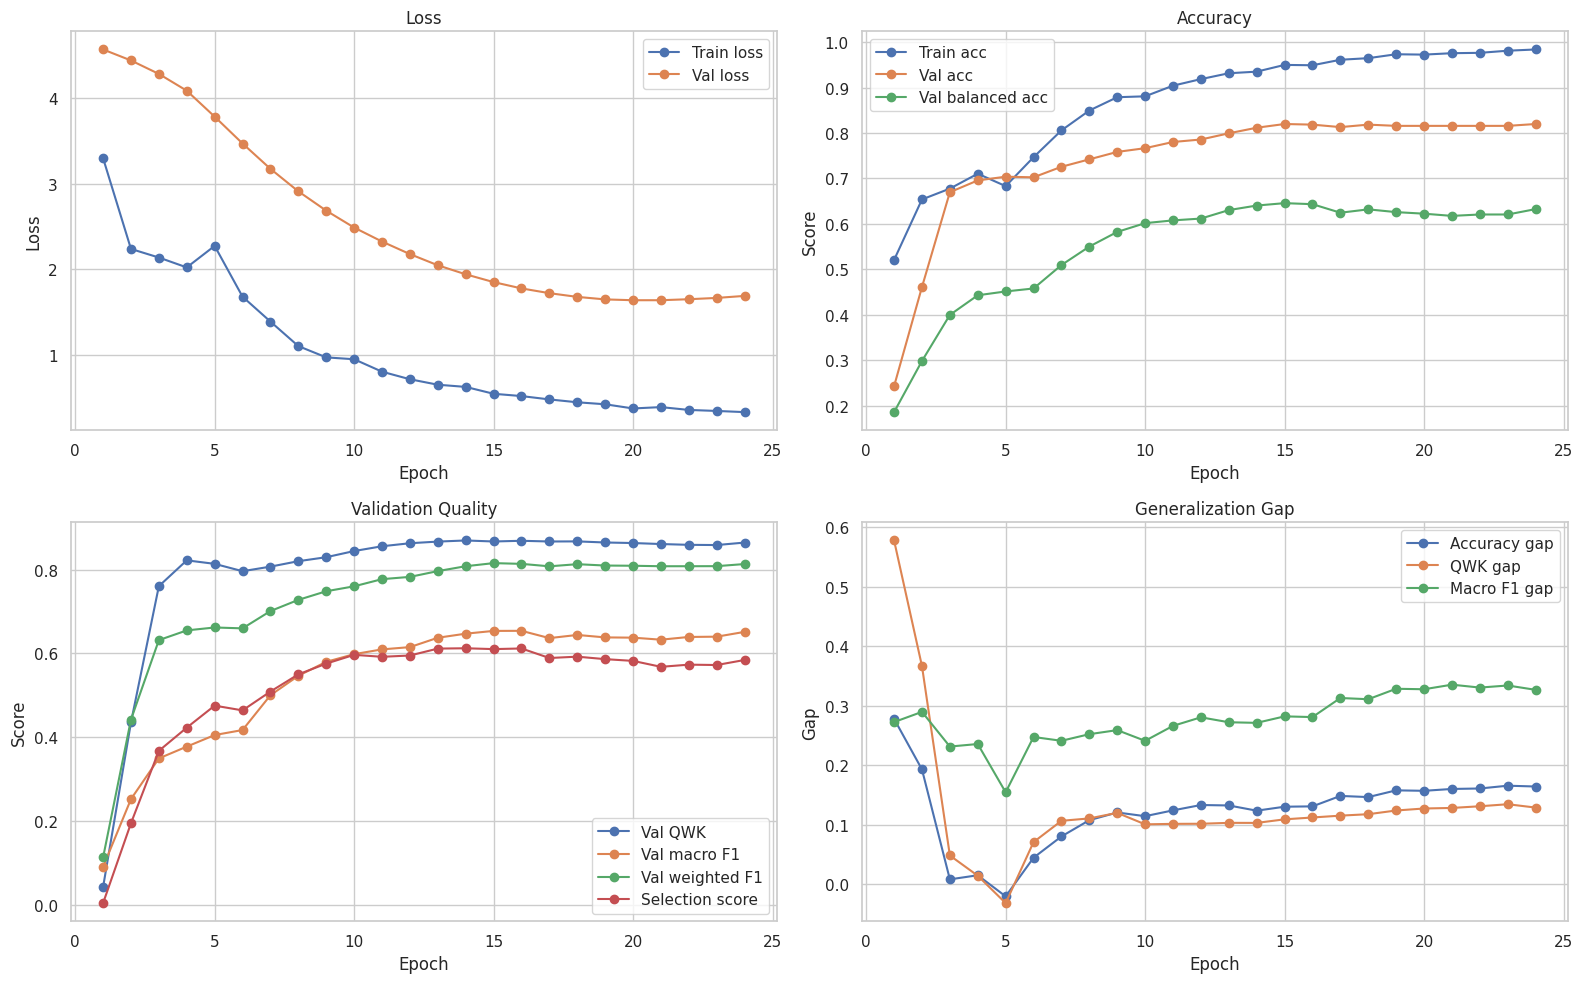

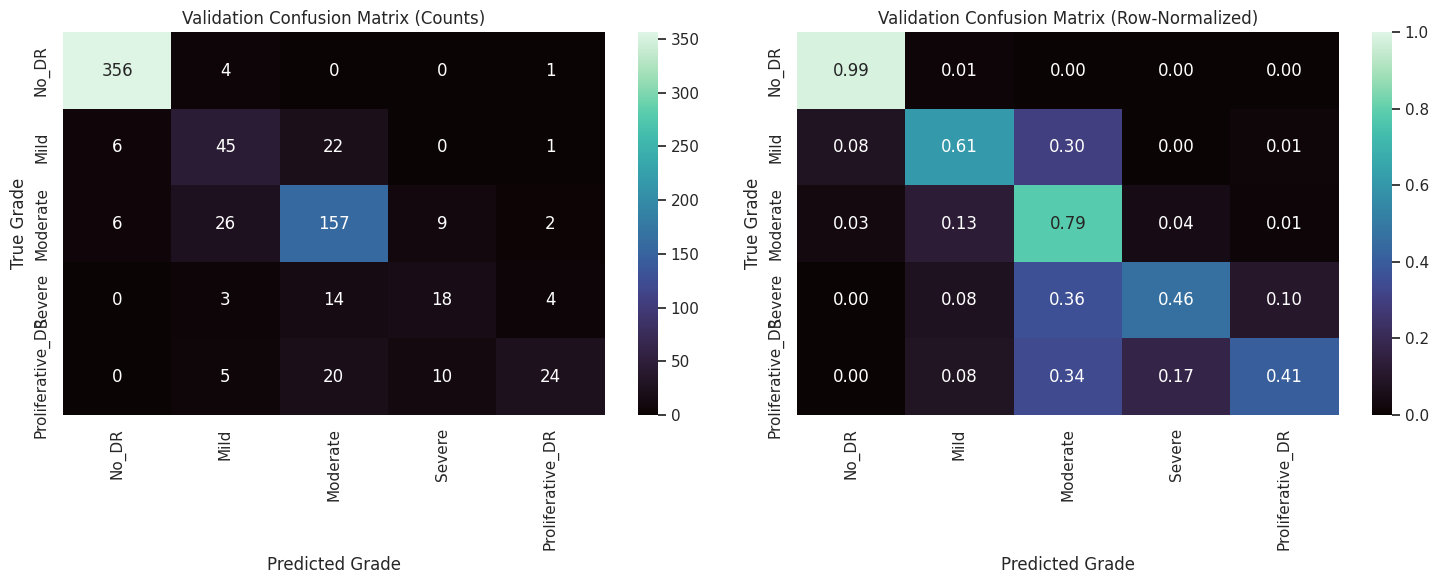

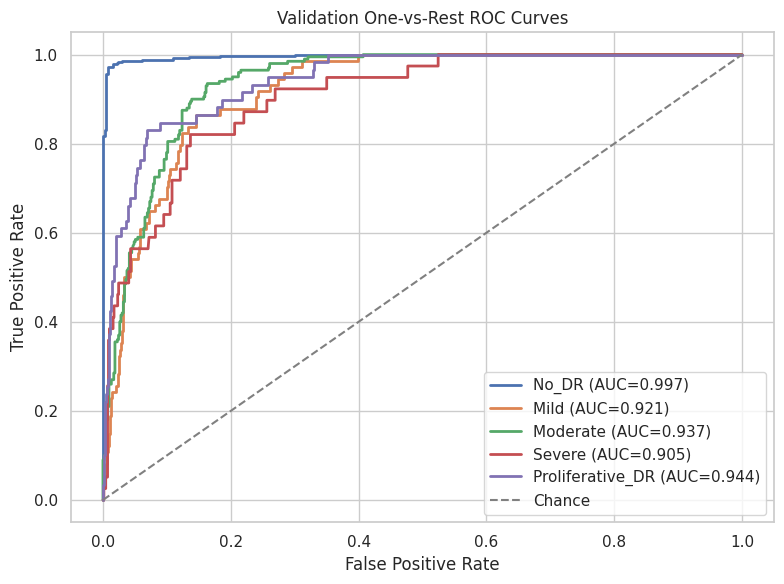

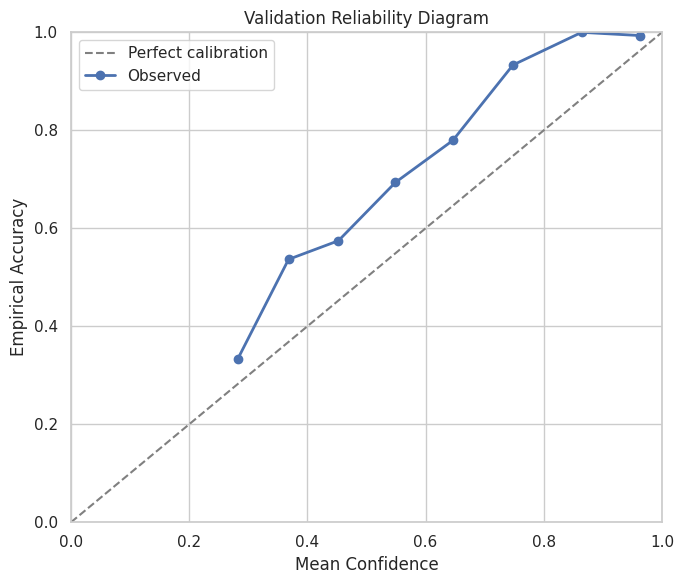

[PosixPath('/kaggle/working/dr_hybrid_project/notebook_artifacts/tables/validation_hard_cases.csv'),
 PosixPath('/kaggle/working/dr_hybrid_project/notebook_artifacts/tables/validation_hard_cases.tex')]

In [15]:
def predict_logits_with_tta(
    model: nn.Module,
    images: torch.Tensor,
    tta_horizontal: bool = False,
) -> torch.Tensor:
    logits = model(images)["logits"]
    if tta_horizontal:
        flipped_images = torch.flip(images, dims=[3])
        if USE_CHANNELS_LAST:
            flipped_images = flipped_images.contiguous(memory_format=torch.channels_last)
        logits = 0.5 * (logits + model(flipped_images)["logits"])
    return logits.float()


def collect_labeled_logits(
    model: nn.Module,
    loader: DataLoader,
    tta_horizontal: bool = False,
) -> tuple[pd.DataFrame, np.ndarray]:
    model.eval()
    all_rows = []
    all_logits = []

    with torch.inference_mode():
        for batch in loader:
            images = prepare_batch_images(batch["image"])
            labels = batch["label"].cpu().numpy()
            with get_autocast_context():
                logits = predict_logits_with_tta(model, images, tta_horizontal=tta_horizontal).cpu().numpy()

            for image_id, image_path, label in zip(
                batch["image_id"],
                batch["image_path"],
                labels,
            ):
                all_rows.append(
                    {
                        "image_id": image_id,
                        "image_path": image_path,
                        "true_label": int(label),
                    }
                )
            all_logits.append(logits)

    if not all_logits:
        return pd.DataFrame(columns=["image_id", "image_path", "true_label"]), np.empty((0, CFG.num_classes), dtype=np.float32)
    return pd.DataFrame(all_rows), np.concatenate(all_logits)


def expected_grade_from_probabilities(probability_array: np.ndarray) -> np.ndarray:
    if len(probability_array) == 0:
        return np.empty((0,), dtype=np.float32)
    grade_values = np.arange(probability_array.shape[1], dtype=np.float32)
    return (probability_array * grade_values[None, :]).sum(axis=1).astype(np.float32)


def predict_from_expected_grade(expected_grade: np.ndarray, decision_thresholds: list[float] | np.ndarray) -> np.ndarray:
    thresholds = np.asarray(decision_thresholds, dtype=np.float32)
    return np.digitize(expected_grade, bins=thresholds, right=False).astype(int)


def threshold_selection_score(metrics: dict[str, float]) -> float:
    return float(
        0.24 * metrics["qwk"]
        + 0.14 * metrics["accuracy"]
        + 0.14 * metrics["macro_f1"]
        + 0.12 * metrics["balanced_accuracy"]
        + 0.22 * metrics["minority_recall"]
        + 0.10 * metrics["min_class_recall"]
        - 0.04 * metrics["ece"]
    )


def fit_ordinal_thresholds(
    probabilities: np.ndarray,
    y_true: np.ndarray,
    cfg: Config,
) -> tuple[np.ndarray, pd.DataFrame]:
    default_thresholds = np.arange(cfg.num_classes - 1, dtype=np.float32) + 0.5
    if len(y_true) == 0:
        threshold_frame = pd.DataFrame(
            {
                "boundary": [f"{CLASS_NAMES[i]} -> {CLASS_NAMES[i + 1]}" for i in range(cfg.num_classes - 1)],
                "default_threshold": default_thresholds,
                "optimized_threshold": default_thresholds,
                "searched": False,
            }
        )
        return default_thresholds, threshold_frame

    expected_grade = expected_grade_from_probabilities(probabilities)
    sorted_scores = np.unique(np.sort(expected_grade))
    midpoint_candidates = (
        (sorted_scores[:-1] + sorted_scores[1:]) / 2.0 if len(sorted_scores) > 1 else np.array([], dtype=np.float32)
    )
    global_candidate_pool = np.unique(
        np.concatenate(
            [
                np.linspace(-0.5, cfg.num_classes - 0.5, cfg.threshold_search_steps, dtype=np.float32),
                midpoint_candidates,
                default_thresholds,
            ]
        )
    )

    thresholds = default_thresholds.copy()
    predictions = predict_from_expected_grade(expected_grade, thresholds)
    best_metrics = compute_metrics(y_true, predictions, probabilities, cfg.num_classes)
    best_score = threshold_selection_score(best_metrics)
    epsilon = 1e-3
    fixed_count = int(cfg.threshold_fixed_lower_boundaries) if cfg.threshold_focus_upper_boundaries_only else 0
    optimized_mask = np.zeros(len(thresholds), dtype=bool)

    for _ in range(cfg.threshold_search_passes):
        improved = False
        for threshold_idx in range(len(thresholds)):
            if threshold_idx < fixed_count:
                continue

            left_boundary = thresholds[threshold_idx - 1] + epsilon if threshold_idx > 0 else -0.5
            right_boundary = (
                thresholds[threshold_idx + 1] - epsilon if threshold_idx + 1 < len(thresholds) else cfg.num_classes - 0.5
            )
            default_center = default_thresholds[threshold_idx]
            candidate_pool = global_candidate_pool[
                (global_candidate_pool >= default_center - cfg.threshold_search_radius)
                & (global_candidate_pool <= default_center + cfg.threshold_search_radius)
            ]
            valid_candidates = candidate_pool[(candidate_pool > left_boundary) & (candidate_pool < right_boundary)]
            if len(valid_candidates) == 0:
                continue

            local_best_threshold = thresholds[threshold_idx]
            local_best_metrics = best_metrics
            local_best_score = best_score
            for candidate in valid_candidates:
                trial_thresholds = thresholds.copy()
                trial_thresholds[threshold_idx] = float(candidate)
                trial_predictions = predict_from_expected_grade(expected_grade, trial_thresholds)
                trial_metrics = compute_metrics(y_true, trial_predictions, probabilities, cfg.num_classes)
                trial_score = threshold_selection_score(trial_metrics)
                if trial_score > local_best_score + 1e-6:
                    local_best_threshold = float(candidate)
                    local_best_metrics = trial_metrics
                    local_best_score = trial_score

            if abs(local_best_threshold - thresholds[threshold_idx]) > epsilon:
                thresholds[threshold_idx] = local_best_threshold
                best_metrics = local_best_metrics
                best_score = local_best_score
                optimized_mask[threshold_idx] = True
                improved = True

        if not improved:
            break

    threshold_frame = pd.DataFrame(
        {
            "boundary": [f"{CLASS_NAMES[i]} -> {CLASS_NAMES[i + 1]}" for i in range(cfg.num_classes - 1)],
            "default_threshold": default_thresholds,
            "optimized_threshold": thresholds,
            "searched": optimized_mask,
        }
    )
    return thresholds, threshold_frame


def select_decision_thresholds(
    probabilities: np.ndarray,
    y_true: np.ndarray,
    cfg: Config,
) -> tuple[np.ndarray | None, pd.DataFrame, pd.DataFrame]:
    default_thresholds = np.arange(cfg.num_classes - 1, dtype=np.float32) + 0.5
    threshold_frame = pd.DataFrame(
        {
            "boundary": [f"{CLASS_NAMES[i]} -> {CLASS_NAMES[i + 1]}" for i in range(cfg.num_classes - 1)],
            "default_threshold": default_thresholds,
            "optimized_threshold": default_thresholds,
            "selected_threshold": default_thresholds,
            "selected_policy": "argmax",
            "selection_reason": "threshold optimization disabled",
        }
    )

    if len(y_true) == 0:
        comparison_frame = pd.DataFrame([{"policy": "argmax", "selected": True}])
        return None, threshold_frame, comparison_frame

    argmax_predictions = probabilities.argmax(axis=1).astype(int)
    argmax_metrics = compute_metrics(y_true, argmax_predictions, probabilities, cfg.num_classes)
    comparison_rows = [{"policy": "argmax", "selected": True, **argmax_metrics}]

    if not cfg.enable_threshold_optimization:
        return None, threshold_frame, pd.DataFrame(comparison_rows)

    optimized_thresholds, optimized_frame = fit_ordinal_thresholds(probabilities, y_true, cfg)
    expected_grade = expected_grade_from_probabilities(probabilities)
    optimized_predictions = predict_from_expected_grade(expected_grade, optimized_thresholds)
    optimized_confidences = probabilities[np.arange(len(optimized_predictions)), optimized_predictions].astype(np.float32)
    optimized_metrics = compute_metrics(
        y_true,
        optimized_predictions,
        probabilities,
        cfg.num_classes,
        predicted_confidences=optimized_confidences,
    )

    max_shift = float(np.abs(optimized_thresholds - default_thresholds).max())
    min_gap = float(np.min(np.diff(optimized_thresholds))) if len(optimized_thresholds) > 1 else float("inf")
    accuracy_drop = float(argmax_metrics["accuracy"] - optimized_metrics["accuracy"])
    qwk_drop = float(argmax_metrics["qwk"] - optimized_metrics["qwk"])
    ece_increase = float(optimized_metrics["ece"] - argmax_metrics["ece"])
    score_gain = float(threshold_selection_score(optimized_metrics) - threshold_selection_score(argmax_metrics))
    advanced_recall_gain = float(optimized_metrics["minority_recall"] - argmax_metrics["minority_recall"])
    min_recall_gain = float(optimized_metrics["min_class_recall"] - argmax_metrics["min_class_recall"])
    searched_boundary_count = int(optimized_frame.get("searched", pd.Series(dtype=bool)).sum()) if "searched" in optimized_frame.columns else 0
    use_optimized = (
        score_gain >= cfg.threshold_min_score_gain
        and advanced_recall_gain >= cfg.threshold_min_advanced_recall_gain
        and min_recall_gain >= cfg.threshold_min_min_recall_gain
        and accuracy_drop <= cfg.threshold_max_accuracy_drop
        and qwk_drop <= cfg.threshold_max_qwk_drop
        and ece_increase <= cfg.threshold_max_ece_increase
        and max_shift <= cfg.threshold_max_shift
        and min_gap >= cfg.threshold_min_gap
        and searched_boundary_count > 0
    )

    selected_policy = "calibrated_thresholds" if use_optimized else "argmax"
    selection_reason = (
        f"accepted | score_gain={score_gain:.4f} | advanced_recall_gain={advanced_recall_gain:.4f} | min_recall_gain={min_recall_gain:.4f}"
        if use_optimized
        else (
            f"rejected | score_gain={score_gain:.4f} | advanced_recall_gain={advanced_recall_gain:.4f} | "
            f"min_recall_gain={min_recall_gain:.4f} | accuracy_drop={accuracy_drop:.4f} | qwk_drop={qwk_drop:.4f} | ece_increase={ece_increase:.4f}"
        )
    )

    threshold_frame = optimized_frame.copy()
    threshold_frame["selected_threshold"] = optimized_thresholds if use_optimized else default_thresholds
    threshold_frame["selected_policy"] = selected_policy
    threshold_frame["selection_reason"] = selection_reason
    threshold_frame["max_shift"] = max_shift
    threshold_frame["min_gap"] = min_gap
    threshold_frame["accuracy_drop_vs_argmax"] = accuracy_drop
    threshold_frame["qwk_drop_vs_argmax"] = qwk_drop
    threshold_frame["ece_increase_vs_argmax"] = ece_increase
    threshold_frame["score_gain_vs_argmax"] = score_gain
    threshold_frame["advanced_recall_gain_vs_argmax"] = advanced_recall_gain
    threshold_frame["min_class_recall_gain_vs_argmax"] = min_recall_gain

    comparison_rows.append({"policy": "calibrated_thresholds", "selected": use_optimized, **optimized_metrics})
    return optimized_thresholds if use_optimized else None, threshold_frame, pd.DataFrame(comparison_rows)


def build_labeled_prediction_frame(
    metadata_frame: pd.DataFrame,
    logits: np.ndarray,
    temperature: float = 1.0,
    decision_thresholds: list[float] | np.ndarray | None = None,
) -> tuple[pd.DataFrame, np.ndarray, dict[str, float]]:
    if len(metadata_frame) == 0 or len(logits) == 0:
        empty_frame = metadata_frame.copy()
        empty_frame["pred_label"] = pd.Series(dtype=int)
        empty_frame["confidence"] = pd.Series(dtype=float)
        empty_frame["expected_grade"] = pd.Series(dtype=float)
        empty_frame["decision_policy"] = pd.Series(dtype=str)
        empty_frame["distance"] = pd.Series(dtype=int)
        empty_probabilities = np.empty((0, CFG.num_classes), dtype=np.float32)
        empty_metrics = compute_metrics(np.array([], dtype=int), np.array([], dtype=int), empty_probabilities, CFG.num_classes)
        return empty_frame, empty_probabilities, empty_metrics

    probability_array = logits_to_probabilities(logits, temperature=temperature)
    expected_grade = expected_grade_from_probabilities(probability_array)
    if decision_thresholds is None:
        predicted_labels = probability_array.argmax(axis=1).astype(int)
        decision_policy = "argmax"
    else:
        predicted_labels = predict_from_expected_grade(expected_grade, decision_thresholds)
        decision_policy = "calibrated_thresholds"

    predicted_confidences = probability_array[np.arange(len(predicted_labels)), predicted_labels].astype(np.float32)
    prediction_frame = metadata_frame.copy()
    prediction_frame["pred_label"] = predicted_labels
    prediction_frame["confidence"] = predicted_confidences.astype(float)
    prediction_frame["expected_grade"] = expected_grade.astype(float)
    prediction_frame["decision_policy"] = decision_policy
    prediction_frame["distance"] = np.abs(
        prediction_frame["pred_label"].to_numpy() - prediction_frame["true_label"].to_numpy()
    ).astype(int)
    metrics = compute_metrics(
        prediction_frame["true_label"].to_numpy(),
        prediction_frame["pred_label"].to_numpy(),
        probability_array,
        CFG.num_classes,
        predicted_confidences=predicted_confidences,
    )
    return prediction_frame, probability_array, metrics


def build_classification_report_frame(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: list[str],
) -> pd.DataFrame:
    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T


def build_confusion_frames(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    matrix = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    count_frame = pd.DataFrame(matrix, index=class_names, columns=class_names)
    normalized_frame = count_frame.div(count_frame.sum(axis=1).replace(0, 1), axis=0)
    return count_frame, normalized_frame


def fit_temperature_scaler(
    calibration_logits: np.ndarray,
    calibration_labels: np.ndarray,
    cfg: Config,
) -> float:
    if len(calibration_labels) == 0:
        return 1.0

    logits_tensor = torch.tensor(calibration_logits, dtype=torch.float32)
    labels_tensor = torch.tensor(calibration_labels, dtype=torch.long)
    temperature = nn.Parameter(torch.ones(1, dtype=torch.float32))
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.LBFGS([temperature], lr=0.05, max_iter=50, line_search_fn="strong_wolfe")

    def closure():
        optimizer.zero_grad()
        clamped_temperature = temperature.clamp(cfg.temperature_min, cfg.temperature_max)
        loss = criterion(logits_tensor / clamped_temperature, labels_tensor)
        loss.backward()
        return loss

    optimizer.step(closure)
    return float(temperature.detach().clamp(cfg.temperature_min, cfg.temperature_max).item())


def summarize_probability_calibration(
    logits: np.ndarray,
    y_true: np.ndarray,
    temperature: float,
    split_name: str,
) -> list[dict[str, float | str]]:
    rows = []
    for setting_name, used_temperature in [
        ("uncalibrated", 1.0),
        ("temperature_scaled", temperature),
    ]:
        probabilities = logits_to_probabilities(logits, temperature=used_temperature)
        predictions = probabilities.argmax(axis=1)
        metrics = compute_metrics(y_true, predictions, probabilities, CFG.num_classes)
        rows.append(
            {
                "split": split_name,
                "setting": setting_name,
                "temperature": float(used_temperature),
                "accuracy": metrics["accuracy"],
                "balanced_accuracy": metrics["balanced_accuracy"],
                "qwk": metrics["qwk"],
                "macro_f1": metrics["macro_f1"],
                "weighted_f1": metrics["weighted_f1"],
                "macro_auc_ovr": metrics["macro_auc_ovr"],
                "nll": metrics["nll"],
                "ece": metrics["ece"],
            }
        )
    return rows


def plot_training_history(history: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.ravel()

    axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="Train loss")
    axes[0].plot(history["epoch"], history["val_loss"], marker="o", label="Val loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["epoch"], history["train_accuracy"], marker="o", label="Train acc")
    axes[1].plot(history["epoch"], history["val_accuracy"], marker="o", label="Val acc")
    axes[1].plot(history["epoch"], history["val_balanced_accuracy"], marker="o", label="Val balanced acc")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].legend()

    axes[2].plot(history["epoch"], history["val_qwk"], marker="o", label="Val QWK")
    axes[2].plot(history["epoch"], history["val_macro_f1"], marker="o", label="Val macro F1")
    axes[2].plot(history["epoch"], history["val_weighted_f1"], marker="o", label="Val weighted F1")
    axes[2].plot(history["epoch"], history["selection_score"], marker="o", label="Selection score")
    axes[2].set_title("Validation Quality")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Score")
    axes[2].legend()

    axes[3].plot(history["epoch"], history["accuracy_gap"], marker="o", label="Accuracy gap")
    axes[3].plot(history["epoch"], history["qwk_gap"], marker="o", label="QWK gap")
    axes[3].plot(history["epoch"], history["macro_f1_gap"], marker="o", label="Macro F1 gap")
    axes[3].set_title("Generalization Gap")
    axes[3].set_xlabel("Epoch")
    axes[3].set_ylabel("Gap")
    axes[3].legend()

    plt.tight_layout()
    plt.show()
    return fig


def plot_confusion_heatmap(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: list[str],
) -> tuple[object, pd.DataFrame, pd.DataFrame]:
    count_frame, normalized_frame = build_confusion_frames(y_true, y_pred, class_names)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.heatmap(count_frame, annot=True, fmt="d", cmap="mako", ax=axes[0])
    axes[0].set_title("Validation Confusion Matrix (Counts)")
    axes[0].set_xlabel("Predicted Grade")
    axes[0].set_ylabel("True Grade")

    sns.heatmap(normalized_frame, annot=True, fmt=".2f", cmap="mako", vmin=0.0, vmax=1.0, ax=axes[1])
    axes[1].set_title("Validation Confusion Matrix (Row-Normalized)")
    axes[1].set_xlabel("Predicted Grade")
    axes[1].set_ylabel("True Grade")
    plt.tight_layout()
    plt.show()
    return fig, count_frame, normalized_frame


def plot_multiclass_roc(y_true: np.ndarray, y_prob: np.ndarray, class_names: list[str]):
    y_true_binary = label_binarize(y_true, classes=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(8, 6))
    plotted_any = False

    for class_idx, class_name in enumerate(class_names):
        positives = y_true_binary[:, class_idx].sum()
        if positives == 0 or positives == len(y_true_binary):
            continue
        fpr, tpr, _ = roc_curve(y_true_binary[:, class_idx], y_prob[:, class_idx])
        auc_value = roc_auc_score(y_true_binary[:, class_idx], y_prob[:, class_idx])
        ax.plot(fpr, tpr, linewidth=2, label=f"{class_name} (AUC={auc_value:.3f})")
        plotted_any = True

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Chance")
    ax.set_title("Validation One-vs-Rest ROC Curves")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    if plotted_any:
        ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
    return fig


def plot_reliability_diagram(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    num_bins: int = 10,
) -> tuple[object, pd.DataFrame]:
    predictions = y_prob.argmax(axis=1)
    confidences = y_prob.max(axis=1)
    correctness = (predictions == y_true).astype(float)
    bin_edges = np.linspace(0.0, 1.0, num_bins + 1)
    rows = []

    for start, end in zip(bin_edges[:-1], bin_edges[1:]):
        if end == 1.0:
            in_bin = (confidences >= start) & (confidences <= end)
        else:
            in_bin = (confidences >= start) & (confidences < end)

        if not np.any(in_bin):
            continue

        rows.append(
            {
                "bin_start": float(start),
                "bin_end": float(end),
                "bin_center": float((start + end) / 2.0),
                "mean_confidence": float(confidences[in_bin].mean()),
                "empirical_accuracy": float(correctness[in_bin].mean()),
                "count": int(in_bin.sum()),
            }
        )

    reliability_frame = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Perfect calibration")
    if len(reliability_frame):
        ax.plot(
            reliability_frame["mean_confidence"],
            reliability_frame["empirical_accuracy"],
            marker="o",
            linewidth=2,
            label="Observed",
        )
    ax.set_title("Validation Reliability Diagram")
    ax.set_xlabel("Mean Confidence")
    ax.set_ylabel("Empirical Accuracy")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()
    return fig, reliability_frame


checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])

calibration_metadata_frame, calibration_logits = collect_labeled_logits(
    model,
    calibration_loader,
    tta_horizontal=CFG.tta_horizontal,
)
calibration_labels = calibration_metadata_frame["true_label"].to_numpy()
temperature = fit_temperature_scaler(calibration_logits, calibration_labels, CFG)
calibration_argmax_frame, calibration_probabilities, calibration_argmax_metrics = build_labeled_prediction_frame(
    calibration_metadata_frame,
    calibration_logits,
    temperature=temperature,
)
decision_thresholds, decision_threshold_frame, calibration_policy_comparison = select_decision_thresholds(
    calibration_probabilities,
    calibration_labels,
    CFG,
)
candidate_thresholds = (
    decision_threshold_frame["optimized_threshold"].to_numpy(dtype=np.float32)
    if "optimized_threshold" in decision_threshold_frame.columns
    else None
)
calibration_candidate_frame = calibration_argmax_frame
calibration_candidate_metrics = calibration_argmax_metrics
if candidate_thresholds is not None and CFG.enable_threshold_optimization:
    calibration_candidate_frame, calibration_probabilities, calibration_candidate_metrics = build_labeled_prediction_frame(
        calibration_metadata_frame,
        calibration_logits,
        temperature=temperature,
        decision_thresholds=candidate_thresholds,
    )

selected_decision_policy = "calibrated_thresholds" if decision_thresholds is not None else "argmax"
if selected_decision_policy == "calibrated_thresholds":
    calibration_prediction_frame = calibration_candidate_frame
    calibration_metrics = calibration_candidate_metrics
else:
    calibration_prediction_frame = calibration_argmax_frame
    calibration_metrics = calibration_argmax_metrics

val_metadata_frame, val_logits = collect_labeled_logits(
    model,
    val_loader,
    tta_horizontal=CFG.tta_horizontal,
)
val_argmax_frame, val_probabilities, val_argmax_metrics = build_labeled_prediction_frame(
    val_metadata_frame,
    val_logits,
    temperature=temperature,
)
val_candidate_frame = val_argmax_frame
val_candidate_metrics = val_argmax_metrics
if candidate_thresholds is not None and CFG.enable_threshold_optimization:
    val_candidate_frame, val_probabilities, val_candidate_metrics = build_labeled_prediction_frame(
        val_metadata_frame,
        val_logits,
        temperature=temperature,
        decision_thresholds=candidate_thresholds,
    )

if selected_decision_policy == "calibrated_thresholds":
    val_prediction_frame = val_candidate_frame
    val_metrics = val_candidate_metrics
else:
    val_prediction_frame = val_argmax_frame
    val_metrics = val_argmax_metrics

class_report_frame = build_classification_report_frame(
    val_prediction_frame["true_label"].to_numpy(),
    val_prediction_frame["pred_label"].to_numpy(),
    CLASS_NAMES,
)

calibration_report = pd.DataFrame(
    summarize_probability_calibration(calibration_logits, calibration_labels, temperature, "Calibration")
    + summarize_probability_calibration(
        val_logits,
        val_prediction_frame["true_label"].to_numpy(),
        temperature,
        "Validation",
    )
)
decision_policy_rows = [
    {"split": "Calibration", "policy": "argmax", "selected": selected_decision_policy == "argmax", **calibration_argmax_metrics},
    {"split": "Validation", "policy": "argmax", "selected": selected_decision_policy == "argmax", **val_argmax_metrics},
]
if candidate_thresholds is not None and CFG.enable_threshold_optimization:
    decision_policy_rows.extend(
        [
            {
                "split": "Calibration",
                "policy": "calibrated_thresholds",
                "selected": selected_decision_policy == "calibrated_thresholds",
                **calibration_candidate_metrics,
            },
            {
                "split": "Validation",
                "policy": "calibrated_thresholds",
                "selected": selected_decision_policy == "calibrated_thresholds",
                **val_candidate_metrics,
            },
        ]
    )
decision_policy_comparison = pd.DataFrame(decision_policy_rows)
best_epoch_frame = pd.DataFrame([checkpoint.get("history_row", {})])
validation_metrics_frame = pd.DataFrame([val_metrics])
hardest_validation_cases = val_prediction_frame.sort_values(["distance", "confidence"], ascending=[False, True]).head(12).copy()
hardest_validation_cases["true_class"] = hardest_validation_cases["true_label"].map(
    lambda class_idx: CLASS_NAMES[int(class_idx)]
)
hardest_validation_cases["pred_class"] = hardest_validation_cases["pred_label"].map(
    lambda class_idx: CLASS_NAMES[int(class_idx)]
)

display(calibration_report.round(4))
display(decision_threshold_frame.round(4))
display(decision_policy_comparison.round(4))
print("Validation TTA:", CFG.tta_horizontal)
print("Learned temperature:", f"{temperature:.4f}")
print("Selected decision policy:", selected_decision_policy)
if decision_thresholds is not None:
    print("Applied decision thresholds:", [f"{threshold:.4f}" for threshold in decision_thresholds])
else:
    print("Applied decision thresholds:", "argmax retained")
display(best_epoch_frame.round(4))
display(validation_metrics_frame.round(4))
display(class_report_frame.round(4))
display(hardest_validation_cases)

training_history_fig = plot_training_history(history_df)
confusion_figure, confusion_count_frame, confusion_normalized_frame = plot_confusion_heatmap(
    val_prediction_frame["true_label"].to_numpy(),
    val_prediction_frame["pred_label"].to_numpy(),
    CLASS_NAMES,
)
roc_figure = plot_multiclass_roc(
    val_prediction_frame["true_label"].to_numpy(),
    val_probabilities,
    CLASS_NAMES,
)
reliability_figure, reliability_bins = plot_reliability_diagram(
    val_prediction_frame["true_label"].to_numpy(),
    val_probabilities,
)

save_figure(training_history_fig, "training_history.png")
save_figure(confusion_figure, "validation_confusion_matrix.png")
save_figure(roc_figure, "validation_roc_curves.png")
save_figure(reliability_figure, "validation_reliability_diagram.png")

export_table_bundle(history_df, "training_history", include_index=False)
export_table_bundle(best_epoch_frame, "best_epoch_metrics", include_index=False)
export_table_bundle(validation_metrics_frame, "validation_metrics", include_index=False)
export_table_bundle(class_report_frame, "validation_classification_report", include_index=True)
export_table_bundle(calibration_report, "calibration_report", include_index=False)
export_table_bundle(decision_threshold_frame, "decision_thresholds", include_index=False)
export_table_bundle(decision_policy_comparison, "decision_policy_comparison", include_index=False)
export_table_bundle(confusion_count_frame, "validation_confusion_matrix_counts", include_index=True)
export_table_bundle(confusion_normalized_frame, "validation_confusion_matrix_normalized", include_index=True)
export_table_bundle(reliability_bins, "validation_reliability_bins", include_index=False)
export_table_bundle(hardest_validation_cases, "validation_hard_cases", include_index=False)

## Confidence-Based Referral

This section implements the proposal idea of **referring uncertain borderline cases** instead of forcing a risky class decision.

To keep the analysis more research-accurate, the referral thresholds are **selected on the calibration split** and only then applied to the validation split.

A sample is referred when either:

- the top probability is too low, or
- the margin between the top two classes is too small **and** those two classes are adjacent grades

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklea

,coverage,referral_rate,kept_accuracy,kept_macro_f1,kept_qwk,avg_confidence,avg_margin,confidence_threshold,margin_threshold
7,0.7602,0.2398,0.8925,0.685,0.9261,0.7329,0.5856,0.5,0.2


,policy,coverage,referral_rate,kept_accuracy,kept_macro_f1,kept_qwk,avg_confidence,avg_margin,confidence_threshold,margin_threshold
0,selected_on_calibration_applied_to_validation,0.7408,0.2592,0.9061,0.7341,0.9114,0.7243,0.573,0.5,0.20
1,default_thresholds_on_validation,0.6057,0.3943,0.9527,0.7207,0.9355,0.7243,0.573,0.6,0.12


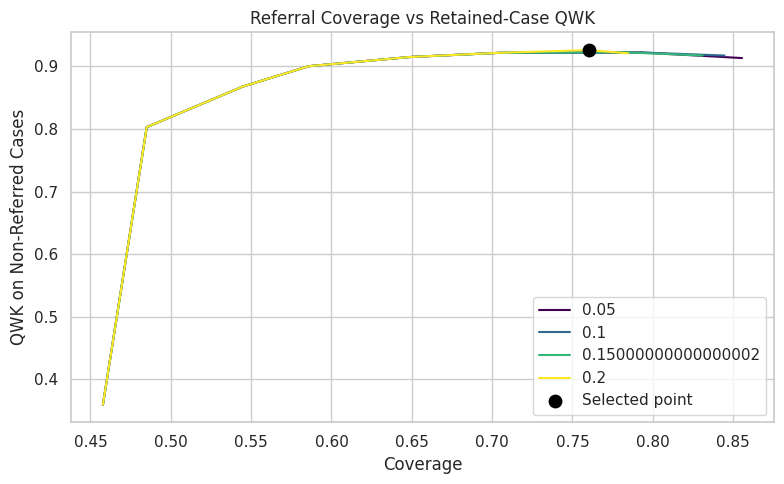

[PosixPath('/kaggle/working/dr_hybrid_project/notebook_artifacts/tables/referral_comparison.csv'),
 PosixPath('/kaggle/working/dr_hybrid_project/notebook_artifacts/tables/referral_comparison.tex')]

In [16]:
def build_referral_mask(
    probabilities: np.ndarray,
    confidence_threshold: float,
    margin_threshold: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    ranking = np.argsort(probabilities, axis=1)[:, ::-1]
    top1 = ranking[:, 0]
    top2 = ranking[:, 1]
    top1_conf = probabilities[np.arange(len(probabilities)), top1]
    top2_conf = probabilities[np.arange(len(probabilities)), top2]
    margins = top1_conf - top2_conf
    adjacent_borderline = np.abs(top1 - top2) == 1
    referred = (top1_conf < confidence_threshold) | ((margins < margin_threshold) & adjacent_borderline)
    return referred, top1_conf, margins, top2


def evaluate_referral_policy(
    y_true: np.ndarray,
    probabilities: np.ndarray,
    confidence_threshold: float,
    margin_threshold: float,
) -> pd.Series:
    referred, confidences, margins, runner_up = build_referral_mask(
        probabilities,
        confidence_threshold=confidence_threshold,
        margin_threshold=margin_threshold,
    )
    predictions = probabilities.argmax(axis=1)
    kept = ~referred

    kept_metrics = compute_metrics(y_true[kept], predictions[kept], probabilities[kept], CFG.num_classes)
    return pd.Series(
        {
            "coverage": float(kept.mean()),
            "referral_rate": float(referred.mean()),
            "kept_accuracy": kept_metrics["accuracy"],
            "kept_macro_f1": kept_metrics["macro_f1"],
            "kept_qwk": kept_metrics["qwk"],
            "avg_confidence": float(confidences.mean()),
            "avg_margin": float(margins.mean()),
        }
    )


def sweep_referral_grid(y_true: np.ndarray, probabilities: np.ndarray) -> pd.DataFrame:
    rows = []
    for confidence_threshold in np.linspace(0.45, 0.80, 8):
        for margin_threshold in np.linspace(0.05, 0.20, 4):
            row = evaluate_referral_policy(y_true, probabilities, confidence_threshold, margin_threshold).to_dict()
            row["confidence_threshold"] = float(confidence_threshold)
            row["margin_threshold"] = float(margin_threshold)
            rows.append(row)
    return pd.DataFrame(rows)


def select_referral_operating_point(referral_grid: pd.DataFrame, min_coverage: float) -> pd.Series:
    candidate_rows = referral_grid[referral_grid["coverage"] >= min_coverage].copy()
    if candidate_rows.empty:
        candidate_rows = referral_grid.copy()
    return candidate_rows.sort_values(
        ["kept_qwk", "kept_macro_f1", "coverage"],
        ascending=False,
    ).iloc[0]


referral_tuning_frame = calibration_prediction_frame if len(calibration_prediction_frame) else val_prediction_frame
referral_tuning_probabilities = calibration_probabilities if len(calibration_prediction_frame) else val_probabilities
referral_selection_split = "calibration" if len(calibration_prediction_frame) else "validation_fallback"

referral_grid = sweep_referral_grid(
    y_true=referral_tuning_frame["true_label"].to_numpy(),
    probabilities=referral_tuning_probabilities,
)
best_referral = select_referral_operating_point(referral_grid, CFG.referral_min_coverage)

referral_summary = evaluate_referral_policy(
    y_true=val_prediction_frame["true_label"].to_numpy(),
    probabilities=val_probabilities,
    confidence_threshold=float(best_referral["confidence_threshold"]),
    margin_threshold=float(best_referral["margin_threshold"]),
)
default_referral_summary = evaluate_referral_policy(
    y_true=val_prediction_frame["true_label"].to_numpy(),
    probabilities=val_probabilities,
    confidence_threshold=CFG.referral_confidence_threshold,
    margin_threshold=CFG.referral_margin_threshold,
)

referral_comparison = pd.DataFrame(
    [
        {
            "policy": f"selected_on_{referral_selection_split}_applied_to_validation",
            **referral_summary.to_dict(),
            "confidence_threshold": float(best_referral["confidence_threshold"]),
            "margin_threshold": float(best_referral["margin_threshold"]),
        },
        {
            "policy": "default_thresholds_on_validation",
            **default_referral_summary.to_dict(),
            "confidence_threshold": CFG.referral_confidence_threshold,
            "margin_threshold": CFG.referral_margin_threshold,
        },
    ]
)
selected_referral_frame = pd.DataFrame([best_referral])
display(selected_referral_frame.round(4))
display(referral_comparison.round(4))

referral_tradeoff_figure = plt.figure(figsize=(8, 5))
sns.lineplot(data=referral_grid, x="coverage", y="kept_qwk", hue="margin_threshold", palette="viridis")
plt.scatter(
    [float(best_referral["coverage"])],
    [float(best_referral["kept_qwk"])],
    color="black",
    s=80,
    label="Selected point",
    zorder=5,
)
plt.title("Referral Coverage vs Retained-Case QWK")
plt.xlabel("Coverage")
plt.ylabel("QWK on Non-Referred Cases")
plt.legend()
plt.tight_layout()
save_figure(referral_tradeoff_figure, "referral_tradeoff.png")
plt.show()

export_table_bundle(referral_grid, "referral_grid", include_index=False)
export_table_bundle(selected_referral_frame, "selected_referral_operating_point", include_index=False)
export_table_bundle(referral_comparison, "referral_comparison", include_index=False)

## Explainability and Quantitative XAI

Two explanation mechanisms are used:

- **Grad-CAM** over the EfficientNet feature maps
- **Attention Rollout** over the DeiT transformer layers

Quantitative checks implemented here:

- **faithfulness**: does confidence drop when the most salient regions are removed?
- **stability**: do explanations remain similar after a small image perturbation?
- **localization hook**: if lesion masks become available later, IoU and Dice can be computed too

In [17]:
def denormalize_image(image_tensor: torch.Tensor) -> np.ndarray:
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = image_tensor.detach().cpu() * std + mean
    image = image.clamp(0, 1).permute(1, 2, 0).numpy()
    return image


def overlay_heatmap(image: np.ndarray, heatmap: np.ndarray, alpha: float = 0.35) -> np.ndarray:
    colorized = plt.cm.jet(heatmap)[..., :3]
    return np.clip((1.0 - alpha) * image + alpha * colorized, 0, 1)


class AttentionRollout:
    def __init__(self, vit_model: nn.Module):
        self.vit_model = vit_model
        self.attention_maps = []
        self.handles = [block.attn.register_forward_hook(self._hook) for block in self.vit_model.blocks]

    def _hook(self, module, inputs, outputs) -> None:
        tokens = inputs[0].detach()
        batch_size, token_count, channels = tokens.shape
        qkv = (
            module.qkv(tokens)
            .reshape(batch_size, token_count, 3, module.num_heads, channels // module.num_heads)
            .permute(2, 0, 3, 1, 4)
        )
        query, key, _ = qkv.unbind(0)
        query = module.q_norm(query)
        key = module.k_norm(key)
        attention = (query * module.scale) @ key.transpose(-2, -1)
        attention = attention.softmax(dim=-1)
        self.attention_maps.append(attention.detach())

    def generate(self, image_tensor: torch.Tensor) -> np.ndarray:
        self.attention_maps.clear()
        with torch.no_grad():
            _ = self.vit_model.forward_features(image_tensor)

        rollout = None
        for attention in self.attention_maps:
            avg_attention = attention.mean(dim=1)
            identity = torch.eye(avg_attention.size(-1), device=avg_attention.device).unsqueeze(0)
            avg_attention = avg_attention + identity
            avg_attention = avg_attention / avg_attention.sum(dim=-1, keepdim=True)
            rollout = avg_attention if rollout is None else avg_attention @ rollout

        mask = rollout[:, 0, 1:]
        side = int(mask.size(-1) ** 0.5)
        mask = mask.reshape(mask.size(0), 1, side, side)
        mask = F.interpolate(mask, size=(CFG.image_size, CFG.image_size), mode="bilinear", align_corners=False)
        mask = mask.squeeze(1)
        mask = (mask - mask.amin(dim=(1, 2), keepdim=True)) / (mask.amax(dim=(1, 2), keepdim=True) - mask.amin(dim=(1, 2), keepdim=True) + 1e-8)
        return mask.detach().cpu().numpy()

    def close(self) -> None:
        for handle in self.handles:
            handle.remove()


def compute_gradcam(model: nn.Module, image_tensor: torch.Tensor, class_idx: int | None = None) -> tuple[np.ndarray, int, np.ndarray]:
    model.eval()
    if image_tensor.ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)
    image_tensor = image_tensor.to(DEVICE)

    with torch.enable_grad():
        outputs = model(image_tensor)
        logits = outputs["logits"]
        target_class = int(logits.argmax(dim=1).item()) if class_idx is None else int(class_idx)
        model.zero_grad(set_to_none=True)
        cnn_maps = outputs["cnn_maps"]
        cnn_maps.retain_grad()
        logits[:, target_class].sum().backward()

        gradients = cnn_maps.grad
        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * cnn_maps).sum(dim=1)
        cam = F.relu(cam)
        cam = F.interpolate(cam.unsqueeze(1), size=image_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze(1)
        cam = (cam - cam.amin(dim=(1, 2), keepdim=True)) / (cam.amax(dim=(1, 2), keepdim=True) - cam.amin(dim=(1, 2), keepdim=True) + 1e-8)

    probabilities = logits.softmax(dim=1).detach().cpu().numpy()[0]
    return cam.detach().cpu().numpy()[0], target_class, probabilities


def explanation_from_method(
    model: nn.Module,
    rollout_helper: AttentionRollout,
    image_tensor: torch.Tensor,
    method_name: str,
    class_idx: int | None = None,
) -> tuple[np.ndarray, int, np.ndarray]:
    if method_name == "Grad-CAM":
        return compute_gradcam(model, image_tensor, class_idx=class_idx)

    with torch.no_grad():
        if image_tensor.ndim == 3:
            image_tensor = image_tensor.unsqueeze(0)
        image_tensor = image_tensor.to(DEVICE)
        outputs = model(image_tensor)
        probabilities = outputs["logits"].softmax(dim=1).detach().cpu().numpy()[0]
        target_class = int(probabilities.argmax()) if class_idx is None else int(class_idx)
        saliency = rollout_helper.generate(image_tensor)[0]
        return saliency, target_class, probabilities


def delete_salient_region(image_tensor: torch.Tensor, saliency_map: np.ndarray, fraction: float = 0.15) -> torch.Tensor:
    threshold = np.quantile(saliency_map.reshape(-1), 1.0 - fraction)
    mask = torch.from_numpy((saliency_map >= threshold).astype(np.float32)).to(image_tensor.device)
    blurred = F.avg_pool2d(image_tensor.unsqueeze(0), kernel_size=21, stride=1, padding=10).squeeze(0)
    return image_tensor * (1.0 - mask.unsqueeze(0)) + blurred * mask.unsqueeze(0)


def localization_overlap(saliency_map: np.ndarray, lesion_mask_path: str | None = None) -> dict[str, float]:
    if lesion_mask_path is None or not Path(lesion_mask_path).exists():
        return {"iou": float("nan"), "dice": float("nan")}

    lesion_mask = Image.open(lesion_mask_path).convert("L").resize((saliency_map.shape[1], saliency_map.shape[0]))
    lesion_mask = (np.array(lesion_mask) > 127).astype(np.uint8)
    saliency_binary = (saliency_map >= np.quantile(saliency_map.reshape(-1), 0.85)).astype(np.uint8)

    intersection = (saliency_binary & lesion_mask).sum()
    union = (saliency_binary | lesion_mask).sum()
    iou = intersection / max(union, 1)
    dice = (2 * intersection) / max(saliency_binary.sum() + lesion_mask.sum(), 1)
    return {"iou": float(iou), "dice": float(dice)}


def evaluate_saliency_suite(
    model: nn.Module,
    dataset: Dataset,
    indices: list[int],
    rollout_helper: AttentionRollout,
    methods: tuple[str, ...] = ("Grad-CAM", "Attention Rollout"),
) -> pd.DataFrame:
    rows = []

    for index in indices:
        sample = dataset[index]
        image_tensor = sample["image"].unsqueeze(0).to(DEVICE)

        for method_name in methods:
            saliency_map, target_class, base_probabilities = explanation_from_method(
                model=model,
                rollout_helper=rollout_helper,
                image_tensor=image_tensor,
                method_name=method_name,
            )

            deleted = delete_salient_region(image_tensor[0], saliency_map, fraction=CFG.deletion_fraction).unsqueeze(0)
            with torch.no_grad():
                deleted_probabilities = model(deleted)["logits"].softmax(dim=1).detach().cpu().numpy()[0]

            noisy_input = image_tensor + torch.randn_like(image_tensor) * CFG.stability_noise_std
            perturbed_map, _, _ = explanation_from_method(
                model=model,
                rollout_helper=rollout_helper,
                image_tensor=noisy_input,
                method_name=method_name,
                class_idx=target_class,
            )

            stability = np.corrcoef(saliency_map.reshape(-1), perturbed_map.reshape(-1))[0, 1]
            overlap = localization_overlap(saliency_map, lesion_mask_path=None)

            rows.append(
                {
                    "image_id": sample["image_id"],
                    "method": method_name,
                    "target_class": target_class,
                    "faithfulness_drop": float(base_probabilities[target_class] - deleted_probabilities[target_class]),
                    "stability_corr": float(stability),
                    "iou": overlap["iou"],
                    "dice": overlap["dice"],
                }
            )

    return pd.DataFrame(rows)


def pick_balanced_indices(frame: pd.DataFrame, max_per_class: int = 2) -> list[int]:
    selected = []
    for label in range(CFG.num_classes):
        label_indices = frame.index[frame["label"] == label].tolist()[:max_per_class]
        selected.extend(label_indices)
    return selected


def plot_explanation_gallery(
    model: nn.Module,
    dataset: Dataset,
    indices: list[int],
    rollout_helper: AttentionRollout,
):
    if not indices:
        print("No samples available for explanation plotting.")
        return None

    fig, axes = plt.subplots(len(indices), 3, figsize=(12, 4 * len(indices)))
    if len(indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, index in enumerate(indices):
        sample = dataset[index]
        image_tensor = sample["image"]
        gradcam_map, gradcam_target, gradcam_probs = compute_gradcam(model, image_tensor.unsqueeze(0), class_idx=None)
        rollout_map, rollout_target, rollout_probs = explanation_from_method(
            model=model,
            rollout_helper=rollout_helper,
            image_tensor=image_tensor.unsqueeze(0),
            method_name="Attention Rollout",
            class_idx=gradcam_target,
        )

        image_rgb = denormalize_image(image_tensor)
        axes[row_idx, 0].imshow(image_rgb)
        axes[row_idx, 0].set_title(
            f"Image\ntrue={CLASS_NAMES[int(sample['label'])]} | pred={CLASS_NAMES[int(gradcam_probs.argmax())]}"
        )
        axes[row_idx, 1].imshow(overlay_heatmap(image_rgb, gradcam_map))
        axes[row_idx, 1].set_title("Grad-CAM")
        axes[row_idx, 2].imshow(overlay_heatmap(image_rgb, rollout_map))
        axes[row_idx, 2].set_title("Attention Rollout")

        for axis in axes[row_idx]:
            axis.axis("off")

    plt.tight_layout()
    plt.show()
    return fig

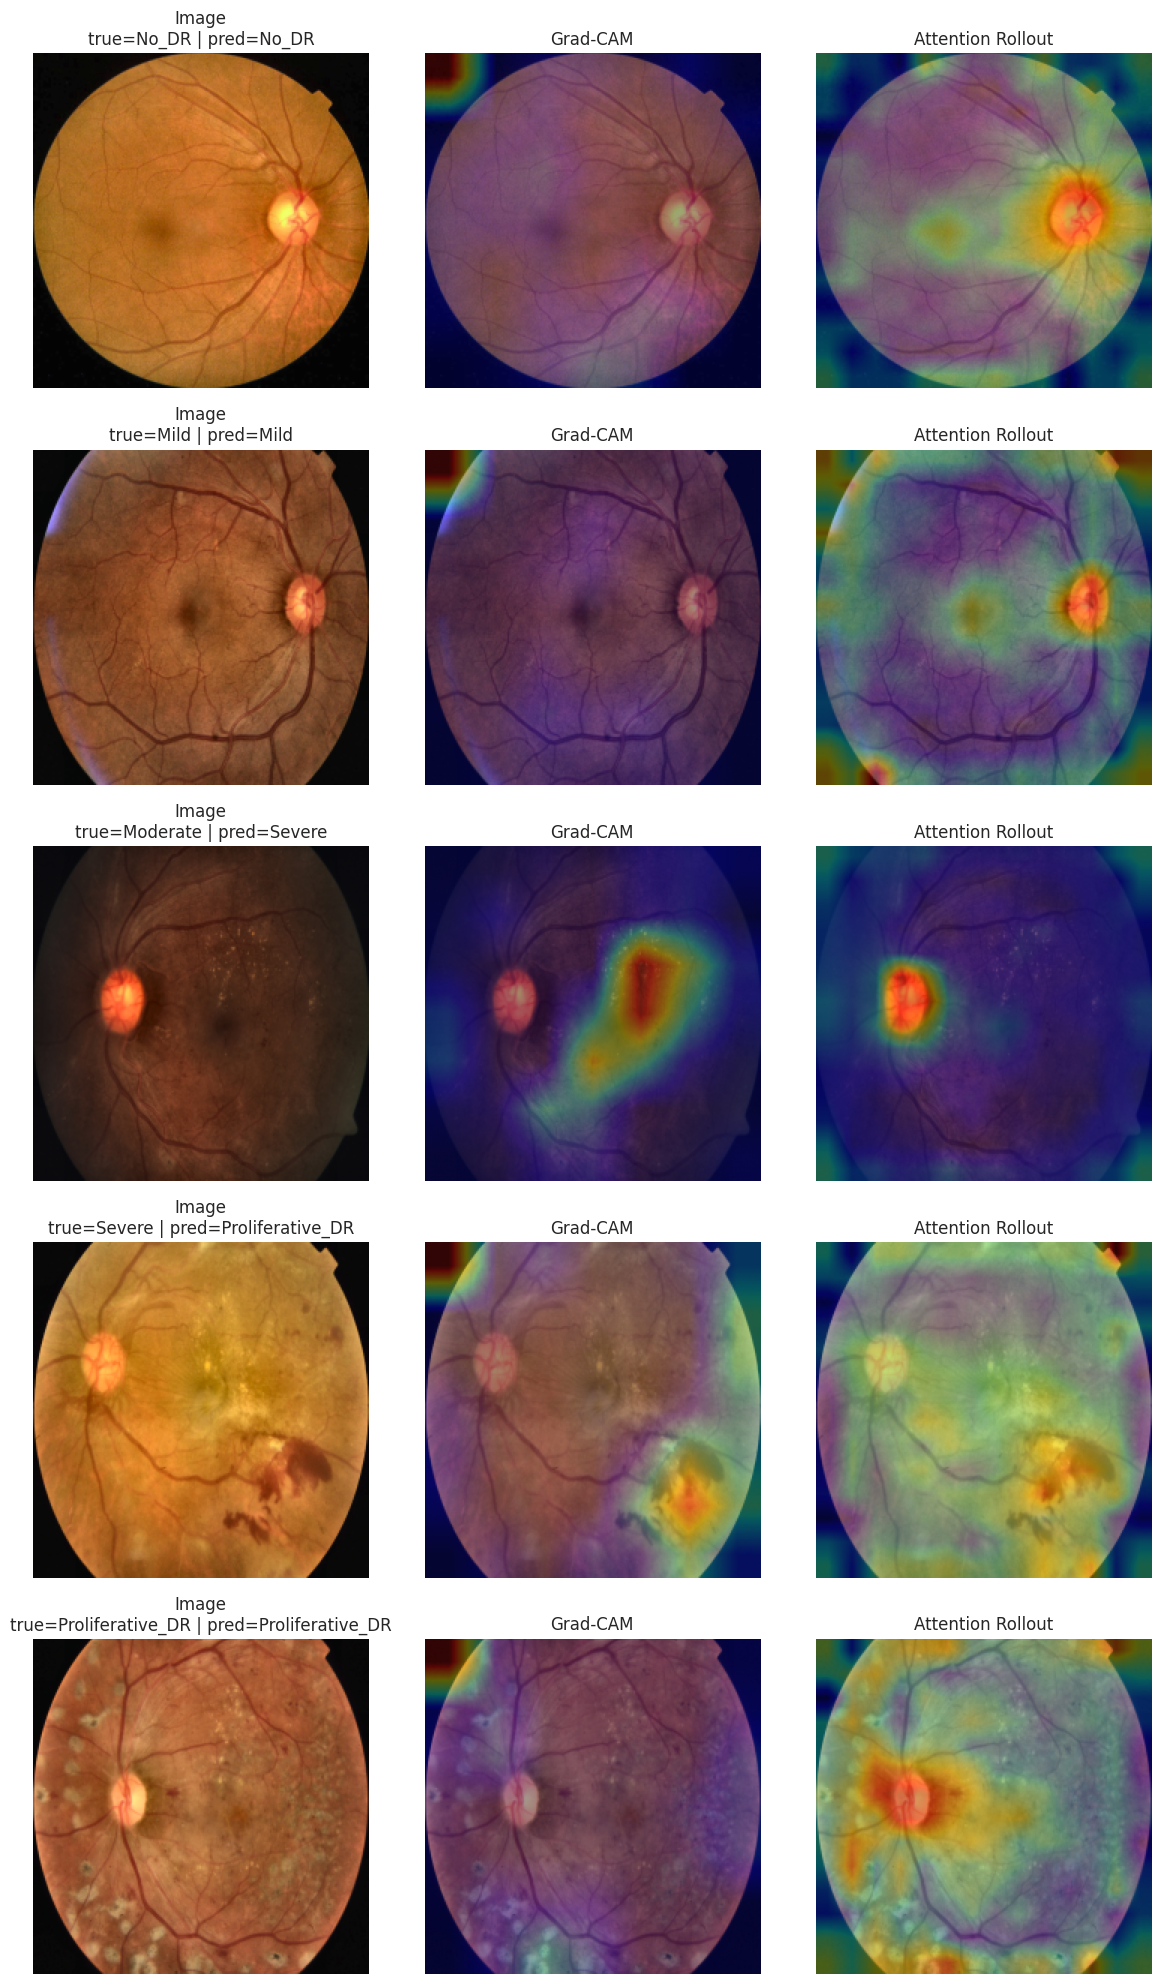

,method,faithfulness_drop,stability_corr,iou,dice
0,Attention Rollout,0.0777,0.9998,NaN,NaN
1,Grad-CAM,0.0866,0.9958,NaN,NaN


,image_id,method,target_class,faithfulness_drop,stability_corr,iou,dice
0,8bf2d925dc0c,Grad-CAM,0,0.116293,0.997777,NaN,NaN
1,8bf2d925dc0c,Attention Rollout,0,0.138939,0.999687,NaN,NaN
2,57a710de68a4,Grad-CAM,0,0.086305,0.995471,NaN,NaN
3,57a710de68a4,Attention Rollout,0,0.072778,0.999772,NaN,NaN
4,2cacdb0dffae,Grad-CAM,0,0.098938,0.981140,NaN,NaN


[PosixPath('/kaggle/working/dr_hybrid_project/notebook_artifacts/tables/xai_sample_results.csv'),
 PosixPath('/kaggle/working/dr_hybrid_project/notebook_artifacts/tables/xai_sample_results.tex')]

In [18]:
rollout_helper = AttentionRollout(model.vit)

gallery_indices = pick_balanced_indices(val_df, max_per_class=1)[: CFG.gradcam_samples]
explanation_gallery_figure = plot_explanation_gallery(model, val_dataset, gallery_indices, rollout_helper)
if explanation_gallery_figure is not None:
    save_figure(explanation_gallery_figure, "xai_explanation_gallery.png")

xai_indices = pick_balanced_indices(val_df, max_per_class=max(1, CFG.xai_eval_samples // CFG.num_classes))
xai_results = evaluate_saliency_suite(model, val_dataset, xai_indices, rollout_helper)
xai_summary_frame = (
    xai_results.groupby("method")[["faithfulness_drop", "stability_corr", "iou", "dice"]]
    .mean()
    .reset_index()
)
display(xai_summary_frame.round(4))
display(xai_results.head())
export_table_bundle(xai_summary_frame, "xai_quantitative_summary", include_index=False)
export_table_bundle(xai_results, "xai_sample_results", include_index=False)

## Test Inference and Submission Export

This final section runs the best saved model on the APTOS test set, exports a Kaggle-style submission file, and packages the paper-ready figures, tables, and notebook outputs into a single downloadable zip bundle.

In [19]:
def is_cuda_oom(error: RuntimeError) -> bool:
    error_text = str(error)
    return "CUDA out of memory" in error_text or "CUDA error: out of memory" in error_text


def predict_test_logits_with_fallback(
    model: nn.Module,
    images: torch.Tensor,
    tta_horizontal: bool = False,
) -> torch.Tensor:
    try:
        with get_autocast_context():
            return predict_logits_with_tta(model, images, tta_horizontal=tta_horizontal)
    except RuntimeError as error:
        if not torch.cuda.is_available() or not is_cuda_oom(error) or images.size(0) <= 1:
            raise
        torch.cuda.empty_cache()
        midpoint = max(1, images.size(0) // 2)
        left_logits = predict_test_logits_with_fallback(model, images[:midpoint], tta_horizontal=tta_horizontal)
        right_logits = predict_test_logits_with_fallback(model, images[midpoint:], tta_horizontal=tta_horizontal)
        return torch.cat([left_logits, right_logits], dim=0)


def collect_unlabeled_logits(
    model: nn.Module,
    loader: DataLoader,
    tta_horizontal: bool = False,
) -> tuple[pd.DataFrame, np.ndarray]:
    model.eval()
    rows = []
    all_logits = []

    with torch.inference_mode():
        for batch in loader:
            images = prepare_batch_images(batch["image"])
            logits_tensor = predict_test_logits_with_fallback(model, images, tta_horizontal=tta_horizontal)
            logits = logits_tensor.cpu().numpy()

            for image_id in batch["image_id"]:
                rows.append(
                    {
                        "image_id": image_id,
                    }
                )
            all_logits.append(logits)

            del images, logits_tensor
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    if not all_logits:
        return pd.DataFrame(columns=["image_id"]), np.empty((0, CFG.num_classes), dtype=np.float32)
    return pd.DataFrame(rows), np.concatenate(all_logits)


def build_unlabeled_prediction_frame(
    metadata_frame: pd.DataFrame,
    logits: np.ndarray,
    temperature: float = 1.0,
    decision_thresholds: list[float] | np.ndarray | None = None,
) -> tuple[pd.DataFrame, np.ndarray]:
    probabilities = logits_to_probabilities(logits, temperature=temperature)
    expected_grade = expected_grade_from_probabilities(probabilities)
    if decision_thresholds is None:
        predicted_labels = probabilities.argmax(axis=1).astype(int)
        decision_policy = "argmax"
    else:
        predicted_labels = predict_from_expected_grade(expected_grade, decision_thresholds)
        decision_policy = "calibrated_thresholds"

    predicted_confidences = probabilities[np.arange(len(predicted_labels)), predicted_labels].astype(np.float32)
    prediction_frame = metadata_frame.copy()
    prediction_frame["diagnosis"] = predicted_labels
    prediction_frame["confidence"] = predicted_confidences.astype(float)
    prediction_frame["expected_grade"] = expected_grade.astype(float)
    prediction_frame["decision_policy"] = decision_policy
    return prediction_frame, probabilities


if "rollout_helper" in globals():
    rollout_helper.attention_maps.clear()
    rollout_helper.close()
    del rollout_helper
model.zero_grad(set_to_none=True)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

aptos_test_dataset = RetinopathyDataset(
    aptos_test_frame,
    eval_transform,
    CFG,
    cache_dir=preprocessed_cache_root / "test" if preprocessed_cache_root is not None else None,
)
test_batch_size = min(CFG.batch_size, 8 if CFG.tta_horizontal else 16)
aptos_test_loader = DataLoader(
    aptos_test_dataset,
    batch_size=test_batch_size,
    shuffle=False,
    **loader_kwargs,
)
print("Test inference batch size:", test_batch_size)

test_metadata_frame, test_logits = collect_unlabeled_logits(
    model,
    aptos_test_loader,
    tta_horizontal=CFG.tta_horizontal,
)
submission_frame, test_probabilities = build_unlabeled_prediction_frame(
    test_metadata_frame,
    test_logits,
    temperature=temperature,
    decision_thresholds=decision_thresholds,
)
submission_path = WORKDIR / "submission_hybrid_dr.csv"
submission_export_frame = submission_frame[["image_id", "diagnosis"]].rename(columns={"image_id": "id_code"})
submission_export_frame.to_csv(submission_path, index=False)
register_artifact(submission_path)

export_table_bundle(val_prediction_frame, "validation_predictions", include_index=False)
export_table_bundle(submission_export_frame, "submission_hybrid_dr", include_index=False)
export_json_artifact(asdict(CFG), "run_config.json")

paper_key_result_rows = [
    {
        "analysis": "validation_overall",
        "accuracy": val_metrics["accuracy"],
        "macro_f1": val_metrics["macro_f1"],
        "qwk": val_metrics["qwk"],
        "macro_auc_ovr": val_metrics["macro_auc_ovr"],
        "ece": val_metrics["ece"],
        "coverage": 1.0,
        "referral_rate": 0.0,
        "faithfulness_drop": float("nan"),
        "stability_corr": float("nan"),
    }
]
for _, referral_row in referral_comparison.iterrows():
    paper_key_result_rows.append(
        {
            "analysis": str(referral_row["policy"]),
            "accuracy": float(referral_row["kept_accuracy"]),
            "macro_f1": float(referral_row["kept_macro_f1"]),
            "qwk": float(referral_row["kept_qwk"]),
            "macro_auc_ovr": float("nan"),
            "ece": float("nan"),
            "coverage": float(referral_row["coverage"]),
            "referral_rate": float(referral_row["referral_rate"]),
            "faithfulness_drop": float("nan"),
            "stability_corr": float("nan"),
        }
    )
for _, xai_row in xai_summary_frame.iterrows():
    paper_key_result_rows.append(
        {
            "analysis": f"xai_{xai_row['method']}",
            "accuracy": float("nan"),
            "macro_f1": float("nan"),
            "qwk": float("nan"),
            "macro_auc_ovr": float("nan"),
            "ece": float("nan"),
            "coverage": float("nan"),
            "referral_rate": float("nan"),
            "faithfulness_drop": float(xai_row["faithfulness_drop"]),
            "stability_corr": float(xai_row["stability_corr"]),
        }
    )
paper_key_results_frame = pd.DataFrame(paper_key_result_rows)
export_table_bundle(paper_key_results_frame, "paper_key_results", include_index=False)

artifact_descriptions = {
    "figures/dataset_distribution.png": "Dataset and source distribution figure for the data section.",
    "figures/training_history.png": "Training and validation learning curves.",
    "figures/validation_confusion_matrix.png": "Validation confusion matrix figure with counts and row-normalized views.",
    "figures/validation_roc_curves.png": "One-vs-rest ROC curves for the validation split.",
    "figures/validation_reliability_diagram.png": "Reliability diagram after temperature scaling.",
    "figures/referral_tradeoff.png": "Coverage versus retained-case QWK referral figure.",
    "figures/xai_explanation_gallery.png": "Qualitative Grad-CAM and Attention Rollout gallery.",
    "tables/dataset_overall_class_counts.csv": "Overall dataset class-count table.",
    "tables/dataset_source_class_counts.csv": "Per-source class-count table.",
    "tables/split_class_distribution.csv": "Train, calibration, and validation split counts by class.",
    "tables/split_source_label_distribution.csv": "Per-source split counts by class.",
    "tables/training_history.csv": "Per-epoch optimization history.",
    "tables/best_epoch_metrics.csv": "Metrics from the checkpoint-selected best epoch.",
    "tables/validation_metrics.csv": "Main validation metrics for the paper results table.",
    "tables/validation_predictions.csv": "Per-sample validation predictions and confidences.",
    "tables/validation_classification_report.csv": "Precision, recall, and F1 by class.",
    "tables/decision_thresholds.csv": "Ordinal thresholds tuned on the calibration split.",
    "tables/decision_policy_comparison.csv": "Argmax versus calibrated-threshold performance comparison.",
    "tables/validation_confusion_matrix_counts.csv": "Raw validation confusion matrix counts.",
    "tables/validation_confusion_matrix_normalized.csv": "Row-normalized validation confusion matrix.",
    "tables/validation_reliability_bins.csv": "Reliability-diagram bin statistics.",
    "tables/validation_hard_cases.csv": "Most difficult validation examples for error analysis.",
    "tables/calibration_report.csv": "Calibration before and after temperature scaling.",
    "tables/referral_grid.csv": "Referral-threshold sweep grid.",
    "tables/selected_referral_operating_point.csv": "Chosen referral operating point.",
    "tables/referral_comparison.csv": "Comparison of selected and default referral policies.",
    "tables/xai_quantitative_summary.csv": "Mean faithfulness and stability by XAI method.",
    "tables/xai_sample_results.csv": "Per-image XAI evaluation results.",
    "tables/submission_hybrid_dr.csv": "Kaggle-format submission table.",
    "tables/paper_key_results.csv": "Compact paper summary table across validation, referral, and XAI.",
    "reports/run_config.json": "Notebook configuration used for the run.",
    "submission_hybrid_dr.csv": "Submission CSV written to the working directory root.",
}
manifest_lines = [
    "# Paper Output Manifest",
    "",
    "This bundle contains manuscript-ready figures, tables, and reproducibility files generated by the notebook.",
    "",
    "## Included Artifacts",
]
for artifact_path in sorted(EXPORTED_ARTIFACTS, key=lambda path: str(path)):
    try:
        relative_path = artifact_path.relative_to(ARTIFACT_DIR)
        relative_text = str(relative_path).replace("\\", "/")
    except ValueError:
        relative_text = artifact_path.name
    description = artifact_descriptions.get(relative_text, "Notebook-generated output artifact.")
    manifest_lines.append(f"- {relative_text}: {description}")
export_text_artifact("\n".join(manifest_lines) + "\n", "paper_output_manifest.md")

download_bundle_path = ARTIFACT_DIR / "hybrid_dr_notebook_outputs.zip"
with zipfile.ZipFile(download_bundle_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for artifact_path in sorted(EXPORTED_ARTIFACTS, key=lambda path: str(path)):
        if artifact_path == download_bundle_path:
            continue
        try:
            arcname = artifact_path.relative_to(ARTIFACT_DIR)
        except ValueError:
            arcname = Path(artifact_path.name)
        archive.write(artifact_path, arcname=str(arcname).replace("\\", "/"))

display(submission_frame.head())
display(FileLink(str(download_bundle_path), result_html_prefix="Download artifact bundle: "))
display(FileLink(str(submission_path), result_html_prefix="Download submission CSV: "))
print("Validation TTA used for export:", CFG.tta_horizontal)
print("Applied temperature scaling to confidence output:", f"{temperature:.4f}")
print("Applied decision policy for export:", selected_decision_policy)
if decision_thresholds is not None:
    print("Applied calibrated ordinal thresholds:", [f"{threshold:.4f}" for threshold in decision_thresholds])
else:
    print("Applied calibrated ordinal thresholds:", "not used (argmax retained)")
print("Submission written to:", submission_path)
print("Artifact bundle written to:", download_bundle_path)

Test inference batch size: 8


,image_id,diagnosis,confidence,expected_grade,decision_policy
0,0005cfc8afb6,1,0.511325,1.529825,argmax
1,003f0afdcd15,3,0.517640,2.767988,argmax
2,006efc72b638,2,0.586366,2.295009,argmax
3,00836aaacf06,2,0.605021,2.221312,argmax
4,009245722fa4,2,0.604323,2.143589,argmax


/kaggle/working/dr_hybrid_project/notebook_artifacts/hybrid_dr_notebook_outputs.zip

/kaggle/working/dr_hybrid_project/submission_hybrid_dr.csv

Validation TTA used for export: True
Applied temperature scaling to confidence output: 0.5000
Applied decision policy for export: argmax
Applied calibrated ordinal thresholds: not used (argmax retained)
Submission written to: /kaggle/working/dr_hybrid_project/submission_hybrid_dr.csv
Artifact bundle written to: /kaggle/working/dr_hybrid_project/notebook_artifacts/hybrid_dr_notebook_outputs.zip


## What To Try Next

- run multi-seed experiments and report mean plus standard deviation for QWK and macro F1
- keep a true external test set if you plan to claim cross-dataset generalization
- compare against single-branch CNN and transformer baselines to make the hybrid contribution easier to justify
- add lesion masks later if you want IoU/Dice-based localization scoring
- extend the calibration study with classwise ECE or confidence histograms if the report needs deeper uncertainty analysis

In [20]:
cache_dir = globals().get("preprocessed_cache_root", WORKDIR / "preprocessed_cache")
cache_dir = Path(cache_dir)

if cache_dir.exists():
    shutil.rmtree(cache_dir)
    print(f"Removed preprocessed cache: {cache_dir}")
else:
    print(f"No preprocessed cache found at: {cache_dir}")

Removed preprocessed cache: /kaggle/working/dr_hybrid_project/preprocessed_cache
